# CNN ile Trafik İşareti Sınıflandırma Projesi



## Proje İçerikleri
* Proje Açıklaması
* Veri setini tanıma.
* Veri setinin önişlenmesi.
* Modelin Oluşturulması.
* Eğitim Fonksiyonu Oluşturması.
* Metrik Hesaplama ve Gösterme Fonksiyonları Oluşturması.
* Hiperparametre Optimizasyonu (GRID Search) ve Yorumlaması.
* Modelin Eğitilmesi.
* Modelin Açıklamaları.
* Sonuç

## Proje Açıklaması
Bu not defteri, 32x32x3 boyutlarında işlenmiş, içerisinde 3 temel veri bulunan (train.pickle, test.pickle, validation.pickle) dosyalarını olduğu ve  içinde `numpy.ndarray` verilerini barındıran Trafik İşaretleri ve sınıflarını belirten bir veri seti ile çalışmaktayız. Bu eğitim, temel sınıflandırma için yapılmıştır ve Konvolüsyonel Sinir Ağı (CNN) modeli geliştirme, eğitme ve değerlendirme projesinin bir parçasıdır.

Tüm süreçleri şeffaf bir şekilde belgelemek için adım adım tasarlanmıştır:

* Veri Yükleme ve Önişleme: Ham verinin Kaggle ortamına yüklenmesi, veri setinin analizi, ağırlıkların hesabı ve modelin performansını artırmak için uygulanan çeşitli önişleme teknikleri (veri artırımı, normalizasyon).

* Model Mimarisi: PyTorch kullanarak dinamik ve özelleştirilebilir bir CNN mimarisinin oluşturulması.

* Hiperparametre Optimizasyonu: Modelin en iyi performansını verecek hiperparametre kombinasyonlarını bulmak için kapsamlı bir Grid Search stratejisinin uygulanması.

* Modelin Eğitilmesi ve Değerlendirilmesi: En iyi performans gösteren modelin çeşitli metrikler (doğruluk, kesinlik, geri çağırma ve F1-skoru, Confusion Matrix, Grad-cam Heatmap) kullanılarak değerlendirilmesi ve sonuçların yorumlanması.

* Transfer Learning ile Modelin Eğitilmesi ve Değerlendirilmesi: Diğerlerine göre düşük veri ile eğitilmiş modelin, birbirinden fazla olan 2 ayrı eğitim veri seti ile 2 aşama daha eğitilmesi ve her eğitim sonrası çeşitli metrikler (doğruluk, kesinlik, geri çağırma ve F1-skoru) kullanılarak değerlendirilmesi ve sonuçların yorumlanması.

Bu not defterini inceleyerek, trafik işaretleri sınıflandırma problemine dair hem teorik hem de pratik bir bakış açısı edinebilirsiniz.

## Veri setini tanıma


## Veri Kümelerini İnceleme ve Eğitim için Seçme
Bu başlıkta, veriseti içerisinde önceden ayarlanmış, toplamda 9 adet veri seti bulunmaktadır. Bu veriler python dili için objeleri bir dosya olarak kaydedilebilmesini sağlayan `pickle` kütüphanesi yardımıyla kaydedilmiş, her biri farklı işlemlerden geçmiş verileri barındırmaktadır.

Bu veriler aşağıdaki gibi belirtilmiştir:
* **data0.pickle - Karıştırma (Shuffling):** Veri setinin sıralamasını rastgele karıştırır. Bu, modelin veri içindeki herhangi bir sırayı öğrenmesini engeller.
* **data1.pickle - Karıştırma, /255.0 Normalizasyonu:** Görüntü piksel değerleri (0-255 arası) 255'e bölünerek 0-1 aralığına getirilir.
* **data2.pickle - Karıştırma, /255.0 + Ortalama Normalizasyonu:** Görüntü piksel değerleri 0-1 aralığına getirilir ve veri kümesinin ortalama piksel değerleri çıkarılır. Bu, veriyi sıfır ortalamaya sahip bir dağılıma taşır.
* **data3.pickle - Karıştırma, /255.0 + Ortalama + Standart Sapma Normalizasyonu:** Veriler 0-1 aralığına getirildikten sonra, ortalaması çıkarılır ve standart sapmaya bölünür. Bu, verinin sıfır ortalama ve bir standart sapmaya sahip olmasını sağlar. Bu, en yaygın ve etkili normalizasyon yöntemlerinden biridir.
* **data4.pickle - Gri Tonlamaya Çevirme (Grayscale), Karıştırma:** Renkli (3 kanal) görüntüler, tek kanallı gri tonlama görüntülerine dönüştürülür.
* **data5.pickle - Gri Tonlamaya Çevirme, Karıştırma, Yerel Histogram Eşitleme (Local Histogram Equalization):** Görüntülerin kontrastını artırarak, özellikle düşük kontrastlı bölgelerdeki detayları belirginleştiren bir yöntemdir. Bu, gri tonlamalı görüntülerde özellikle faydalıdır.
* **data6.pickle - Gri Tonlamaya Çevirme, Karıştırma, Yerel Histogram Eşitleme, /255.0 Normalizasyonu:** Önceki adımlardaki işlemlere ek olarak, piksel değerleri 0-1 aralığına normalleştirilir.
* **data7.pickle - Gri Tonlamaya Çevirme, Karıştırma, Yerel Histogram Eşitleme, /255.0 + Ortalama Normalizasyonu:** Önceki adımlardaki işlemlere ek olarak, ortalama normalizasyonu uygulanır.
* **data8.pickle - Gri Tonlamaya Çevirme, Karıştırma, Yerel Histogram Eşitleme, /255.0 + Ortalama + Standart Sapma Normalizasyonu:** Bu, listedeki tüm ön işleme adımlarını içeren en kapsamlı yöntemdir. Görüntüler hem kontrast hem de dağılım olarak optimize edilmiş olur.
Bu, modelinizi eğitmeden önce veriyi düzenleme, temizleme ve dönüştürme sürecini kapsar.
* **train.pickle - Eğitim verilerinin bir görsel olacak şekilde (32,32,3) tanımlandığı `features`, `labels`, `size` ve `coords` verilerinin yer aldığı dosyadır.
* **test.pickle - Test verilerinin bir görsel olacak şekilde (32,32,3) tanımlandığı `features`, `labels`, `size` ve `coords` verilerinin yer aldığı dosyadır.
* **valid.pickle - Doğrulama verilerinin bir görsel olacak şekilde (32,32,3) tanımlandığı `features`, `labels`, `size` ve `coords` verilerinin yer aldığı dosyadır.

---

### Kullanılan Veri Seti ve Yorumları

Bu başlıkta seçilen eğitim veri seti `train.pickle`, test veri seti olarak `test.pickle` ve doğrulama veri seti için `valid.pickle` dosyaları belirlenmiştir. Bu veri seti, her birinde olduğu gibi eğitim verilerinin sınıflara oranları birbirine eşit olmasıyla birlikte gereken normalizasyon, veri artırımı işlemleri görmemiş ham veri olmasıdır. Bu ham veri, standart bir görsel verisi (H,W,C) olarak içermektedir. Bu veriler 0-255 değerleri arasında yer alan pikselleri temsil etmektedir.

#### Veri Seti İçeriği

Veri seti içerisindeki temel veriler Sözlük formatında yer almaktadır.

In [13]:
# Verilerin açıklamaları ve içinde bulunduğu klasörlerin ve isimlerin tanımlanması.

input_path = "/kaggle/input" # kaggle input yolu
dataset_name = "traffic-signs-preprocessed" # veri setinin ismi

label_name = "label_names.csv" # sınıfların yer aldığı dosya yolu
test_samples_name = "test.pickle" # veri setinin yer aldığı dosya yolu
train_samples_name = "train.pickle" # veri setinin yer aldığı dosya yolu
valid_samples_name = "valid.pickle" # veri setinin yer aldığı dosya yolu

### Veri Setinin Sınıflarının İncelenmesi

Belirtilen veri setinin yanı sıra diğer verilerde de aynı sınıflar yer almaktadır. Bu sınıflar sırasıyla aşağıdaki gibidir.

* Speed limit (20km/h)
* Speed limit (30km/h)
* Speed limit (50km/h)
* Speed limit (60km/h)
* Speed limit (70km/h)
* Speed limit (80km/h)
* End of speed limit (80km/h)
* Speed limit (100km/h)
* Speed limit (120km/h)
* No passing
* No passing for vehicles over 3.5 metric tons
* Right-of-way at the next intersection
* Priority road
* Yield
* Stop
* No vehicles
* Vehicles over 3.5 metric tons prohibited
* No entry
* General caution
* Dangerous curve to the left
* Dangerous curve to the right
* Double curve
* Bumpy road
* Slippery road
* Road narrows on the right
* Road work
* Traffic signals
* Pedestrians
* Children crossing
* Bicycles crossing
* Beware of ice/snow
* Wild animals crossing
* End of all speed and passing limits
* Turn right ahead
* Turn left ahead
* Ahead only
* Go straight or right
* Go straight or left
* Keep right
* Keep left
* Roundabout mandatory
* End of no passing
* End of no passing by vehicles over 3.5 metric ...

Toplamda 43 sınıf içeren veri seti, diğer 3 veri içerisindeki `labels` anahtarı ile 0-42 sayıları arası eşleşmektedir.

In [14]:
import matplotlib.pyplot as plt
import os # dosya yolları, erişim vs. kullanımı.
import pickle # serialize edilip kaydedilmiş veriyi tekrardan okuyabilmek için.
import numpy as np # lineer cebir işlemleri.
import pandas as pd # veri işleme (csv dosyası okuma.)

#fonksiyon kısaltılması, uzun yazmanın önüne geçmek için bu şekilde yazılmıştır.
join = os.path.join

dataset_path = join(input_path,dataset_name) #veri seti yolunu tanımlar.

#Sınıf Dosyaları, pandas kütüphanesi ile okunur.
labels = pd.read_csv(join(dataset_path,label_name))

print(labels)

    ClassId                                           SignName
0         0                               Speed limit (20km/h)
1         1                               Speed limit (30km/h)
2         2                               Speed limit (50km/h)
3         3                               Speed limit (60km/h)
4         4                               Speed limit (70km/h)
5         5                               Speed limit (80km/h)
6         6                        End of speed limit (80km/h)
7         7                              Speed limit (100km/h)
8         8                              Speed limit (120km/h)
9         9                                         No passing
10       10       No passing for vehicles over 3.5 metric tons
11       11              Right-of-way at the next intersection
12       12                                      Priority road
13       13                                              Yield
14       14                                            

### Pickle Kütüphanesi ve Verilerin İncelenmesi

Bu kısımda öncelikle `pickle` kütüphanesinin tanımını, ve sonrasında eğitim, test ve validasyon verilerinin temel olarak incelenmesi anlatılacaktır.




#### Pickle Kütüphanesi Nedir?

Pickle, Python'da nesne serileştirme ve seri dışı bırakma işlemlerini gerçekleştiren bir kütüphanedir. Basitçe söylemek gerekirse, Python nesnelerini (listeler, sözlükler, sınıflar, vb.) bir dosya veya veritabanında saklanabilecek, taşınabilecek veya ağ üzerinden gönderilebilecek bir byte akışına (bayt dizisi) dönüştürür. Bu işleme serileştirme (pickling) denir.

Tersine işlem ise, bayt akışını tekrar orijinal Python nesnesine dönüştürmektir; bu da seri dışı bırakma (unpickling) olarak adlandırılır.

In [15]:
# Serileştirilmiş ve kaydedilmiş veri setinin okunması.
def load_pickle_file(filename:str)->any:
    file = open(filename,"rb") # dosya bayt şeklinde okunur
    data = pickle.load(file) # pickle ile yüklenmesi sağlanır.
    file.close() # dosya kapatılır.
    return data

#### Verilerin İncelenmesi

Veriler, temel olarak 3 şekilde ayrılmıştır. Bunlar;

* **Eğitim verisi**: Eğitim için sınıf dağılımlarının neredeyse eşit olduğu, diğer verilere göre toplamın %70'lik bir kısmını oluşturduğunu söyleyebildiğimiz verilerdir.

* **Test Verisi**: İkinci büyük veri bulunduran bir diğer veri grubudur. Bu veriler sınıflara eşit olarak dağıtılmamış, en temel görevi tarafsız olarak benzersiz olan verilerle modelleri test etmemizi sağlayan veriler topluluğudur.

* **Validasyon Verisi**: Bu veri, hiperparametre optimizasyonu için gerekli olan, içerdiği veri en düşük olan verilerdir.

Bu bilgiler, içerdiği veriler bakımından bize en temel bilgiyi vermektedir. Bu bilgiler boyutları ve katmanları gibi düşünülebilir.

##### Verilerin Boyutları

Verilerin boyutları aşağıdaki şekilde belirtilmiştir.

* x_train: (34799, 32, 32, 3)
* y_train: (86989,)
* x_test: (12630, 32, 32, 3)
* y_test: (12630,)
* x_validation: (4410, 32, 32, 3)
* y_validation: (4410,)

Çıkarılması gereken sonuçlar aşağıdaki gibidir;
* Ham olarak 34799 adet eğitim verisi ve sınıfları yer almaktadır.
* Ham olarak 12630 adet tarafsız test verisi ve sınıfları yer almaktadır.
* Ham olarak 4410 adet hiperparametre optimizasyonu için verileri ve sınıfları yer almaktadır.

---
X verilerinin katmanlarının tanımı, `(N,H,W,C)` gibi düşünerek aşağıdaki gibi yapabiliriz.

* **N**: İçerdiği toplam veriyi temsil eder.
* **H**: Görselin yüksekliğini temsil eder.
* **W**: Görselin genişliğini temsil eder.
* **C**: Görselin içerdiği 3 renk kanalını temsil eder. Bunlar `(R,G,B)` şeklinde kırmızı, yeşil ve mavi olarak gruplandırılır.

Y verileri, katmanı içerisinde sadece `N`kadar veri içerdiğini belirtmektedir.

In [16]:
# Eğitim, Test ve Doğrulama verilerinin yüklenmesi ve düzenlenmesi.

train_pickle = load_pickle_file(join(dataset_path,train_samples_name))
test_pickle = load_pickle_file(join(dataset_path,test_samples_name))
valid_pickle = load_pickle_file(join(dataset_path,valid_samples_name))

print(train_pickle.keys()) # İçerdiği sözlüğün anahtarlarını yazdırır.
print(test_pickle.keys()) # İçerdiği sözlüğün anahtarlarını yazdırır.
print(valid_pickle.keys()) # İçerdiği sözlüğün anahtarlarını yazdırır.

train_set = {
    "samples": train_pickle.get("features",[]),
    "labels": train_pickle.get("labels",[])
}
test_set = {
     "samples": test_pickle.get("features",[]),
    "labels": test_pickle.get("labels",[])
}
valid_set = {
     "samples": valid_pickle.get("features",[]),
    "labels": valid_pickle.get("labels",[])
}

print(f"""
{'=' * 50}

Verilerin Tipleri:

X_train: {type(train_set["samples"])}
Y_train: {type(train_set["labels"])}

X_test: {type(test_set["samples"])}
Y_test: {type(test_set["labels"])}

X_validation: {type(valid_set["samples"])}
Y_validation: {type(valid_set["labels"])}

{'=' * 50}
Boyut Değerleri:

x_train: {train_set["samples"].shape}
y_train: {train_set["labels"].shape}

x_test: {test_set["samples"].shape}
y_test: {test_set["labels"].shape}

x_valid: {valid_set["samples"].shape}
y_valid: {valid_set["labels"].shape}

{'=' * 50}

""")

dict_keys(['coords', 'labels', 'features', 'sizes'])
dict_keys(['sizes', 'coords', 'features', 'labels'])
dict_keys(['coords', 'labels', 'features', 'sizes'])


Verilerin Tipleri:

X_train: <class 'numpy.ndarray'>
Y_train: <class 'numpy.ndarray'>

X_test: <class 'numpy.ndarray'>
Y_test: <class 'numpy.ndarray'>

X_validation: <class 'numpy.ndarray'>
Y_validation: <class 'numpy.ndarray'>

Boyut Değerleri:

x_train: (34799, 32, 32, 3)
y_train: (34799,)

x_test: (12630, 32, 32, 3)
y_test: (12630,)

x_valid: (4410, 32, 32, 3)
y_valid: (4410,)





### Verilerin Görselleştirilerek İncelenmesi

Test verilerini baz alarak bu kısımda bir tablo üzerinde 43 adet sınıf ve sınıfı içeren bir görseli örnek olarak sunma amacıyla oluşturulmuştur.

Bu kısım, eğitim için bize gerekli olan görsellerin kısa bir önizlemesini içermektedir. Eğitimin en temeli ise veriyi tanımak olarak söylenebilir. Bu görsellerin yükseklik ve genişliğine göre netliği, objenin konumu gibi en temel kavramları göstermektedir.

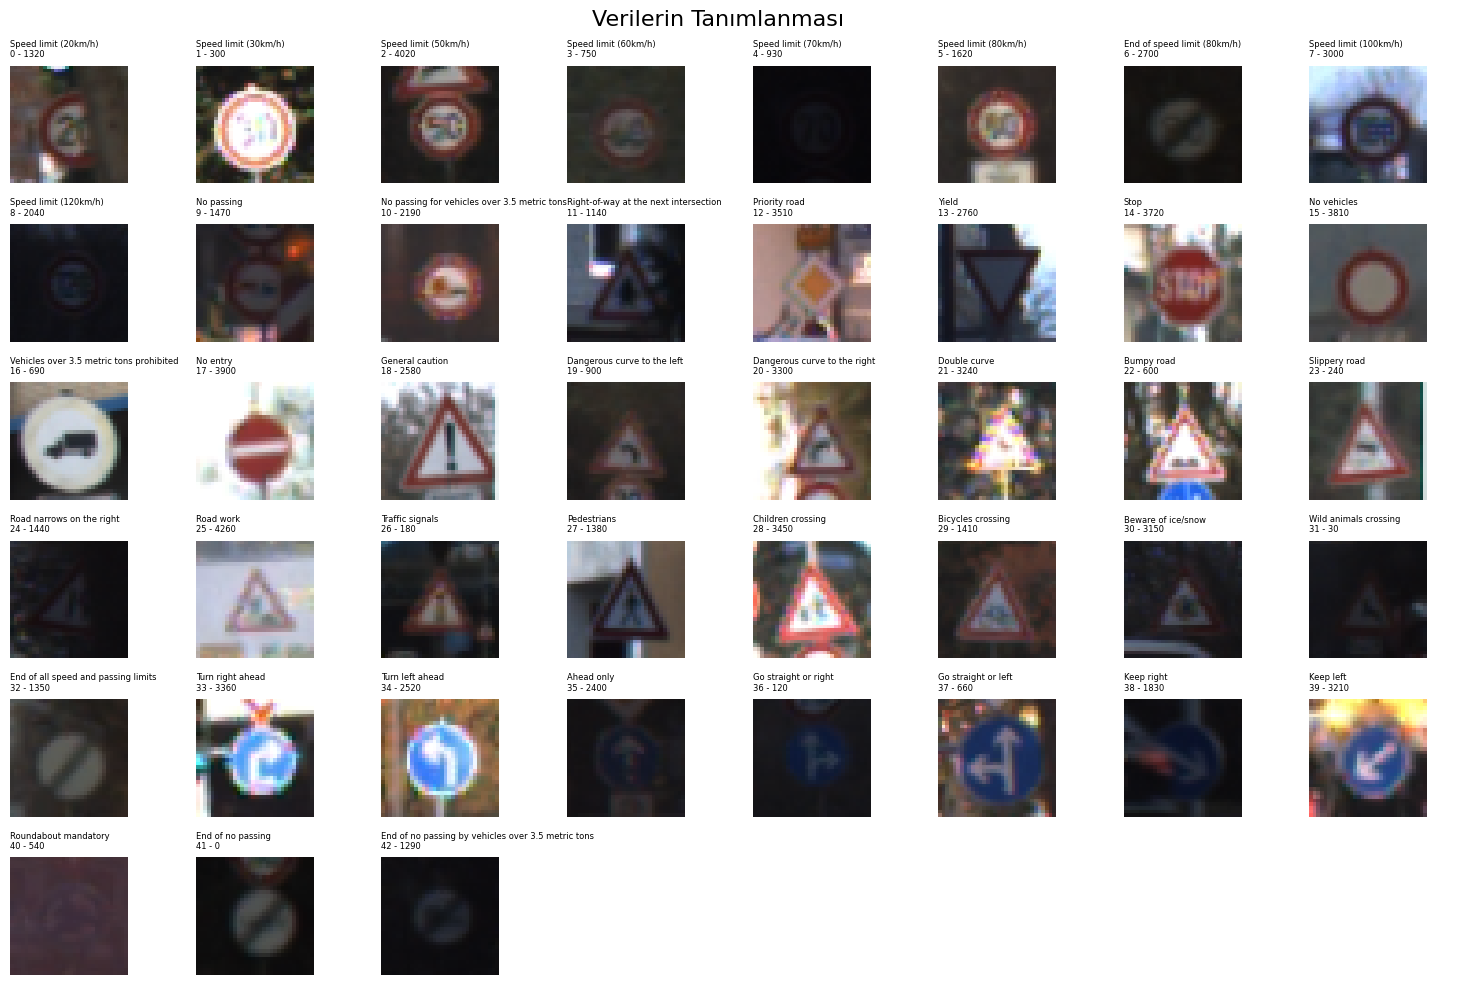

In [17]:
temp_samples = labels["ClassId"].tolist() # Sınıf numaralarının alınması ve geçici liste oluşturulması.
class_labels = labels.to_dict()["SignName"] # sınıfların isimlerinin alınması.
image_samples = {}


for index,class_id in enumerate(valid_set["labels"]):

    # Geçici liste kontrolü.
    if class_id not in temp_samples:
        continue

    # Verileri (H,W,C) şekline dönüştürme ve sözlüğe kaydetme
    sample = valid_set["samples"][index]
    image_samples[class_id] = {
            "image": sample,
            "label" : class_labels[class_id],
            "id"    : class_id,
            "index": index
        }
    temp_samples.remove(class_id)
    if(len(temp_samples) == 0):
        break




# Alt grafiklerin düzenini ayarla (örneğin 6 satır, 8 sütun)
rows = 6
cols = 8
num_samples = len(image_samples) # örnek sayısı

# Toplam 43 fotoğraf için 6x8'lik bir figür oluştur
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
fig.suptitle('Verilerin Tanımlanması', fontsize=16)

axes = axes.flatten()  # 2D array'i 1D'ye çevirerek döngüyü kolaylaştır

for i in range(num_samples):
    # Sözlükteki anahtarı al
    class_id = i

    # İlgili veriyi çek
    image = image_samples[class_id]["image"]
    label = image_samples[class_id]["label"]
    class_id = image_samples[class_id]["id"]
    index = image_samples[class_id]["index"]

    # Görüntüyü doğru alt grafiğe yerleştir
    ax = axes[i]
    image = image.astype(np.uint8)
    ax.imshow(image)
    ax.set_title(f"{label}\n{class_id} - {index}", fontsize=6,loc="left")
    ax.axis('off')  # Eksenleri gizle

# Geriye kalan boş alt grafikleri temizle
for j in range(num_samples, len(axes)):
    axes[j].axis('off')

# Başlıkların ve etiketlerin düzenli görünmesini sağla
plt.tight_layout()
plt.show()

### Sınıf Dağılımı Histogramı

Bu kısımda eğitim, test ve validasyon verilerinin sınıflara göre örnek dağılımları incelenecektir.



#### Fonksiyon oluşturma


* **Hesaplama Fonksiyonu**: Fonksiyon oluşturarak verileri sınıflara göre rahatlıkla hesaplamak ve grafikte göstermek için yapılmıştır. `Numpy` kütüphanesi ile Y verilerinin sözlük formatında sınıf numarası ve kaç adet veri içerdiği hesaplanmıştır. Bu hesaplama sonrası sınıfın ismini, numarasına göre listeden alınarak sınıf isimleri ve bu sınıf örneklerinin sayısı şeklinde `Tuple` tipinde vermesi amaçlanmıştır.

* **Grafik Şeklinde Gösterme Fonksiyonu**: Bu fonksiyonda sınıfı ve örnek sayılarını içeren liste ile bir figür oluşturulmuştur. Örnek etiketleri ve Örnek sayıları olacak şekilde görsel olarak incelemede kolaylık sağlanması amaçlanmıştır.

In [18]:
# Sınıf Dağılımı Histogramı fonksiyon tanımları.

from typing import Tuple,List

# Histogram hesplama
def class_distribution_histogram_calculate(y_sample:np.ndarray)->Tuple[List[str],List[int]]:

    classes,numbers = np.unique(y_sample,return_counts=True) # her bir sınıf için kaç tane örnek içerdiğini hesaplamaktadır.
    labels_str_list = labels["SignName"].tolist() # trafik işaretlerinin tamamının isimleri bir listede içerir.

    classes = list(labels_str_list[c] for c in classes) # içeren sınıfların isimleri bir liste içerisine tanımlanır.

    return classes,numbers

# Histogram gösterimi
def class_distribution_histogram_show(classes:List[str],numbers:List[int]):
    plt.figure(figsize=(15, 6))  # grafiğin boyutunu ayarlar (genişlik, yükseklik)
    plt.bar(classes, numbers)   # sütun grafiğini oluştur.

    # Grafik Detayları
    plt.title('Sınıflara Göre Veri Dağılımı Histogramı') # grafiğe başlık ekle
    plt.xlabel('Sınıf Etiketleri')                      # X eksenine etiket ekle
    plt.ylabel('Örnek Sayısı (Frekans)')                # Y eksenine etiket ekle
    plt.xticks(classes, rotation=90, fontsize=8) # X eksenindeki etiketleri 90 derece döndür (okunması için)
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Arka plana yatay çizgiler ekle
    plt.tight_layout() # grafiğin düzgün sığmasını sağla
    plt.show() # grafiği göster



#### Verilerin Dağılımı Histogram Grafiklerinin İncelenmesi

Elimizdeki eğitim, test ve validasyon verilerinin sayılarını incelemek için yukarıda belirtilen fonksiyonlar ile önce sınıflar ve örnek sayıları hesaplanmış, sonraki aşamada gösterilmesi sağlanmıştır.

Bu veriler ile çıkarılacak sonuçlar şunlardır;

* Eğitim verileri toplamda 34799 veri ile sınıflarına göre eşit dağıtılamamış şekilde yer almaktadır..

* Validasyon verilerinin sınıflara göre eşit dağıtılmadığı görülmüş, bu veriler ile hiperparemetre optimizasyonu için tarafsız bir veri olması hedeflenmiştir. Toplamda 4410 veri içermektedir. En kötü senaryo düşünülerek eğitimdeki sonuçları daha iyi bir şekilde yorumlanması amaçlanmıştır.

* Test verilerinin sınıflara göre eşit dağıtılmadığı görülmüştür. Tarafsız veri ile eğitimlerin test edilmesi amaçlanmıştır. Toplamda 12630 veri yer almaktadır. Hangi verinin ne seviyede öğrenildiğini görebilmek için iyi oluşturulduğu düşünülmektedir.

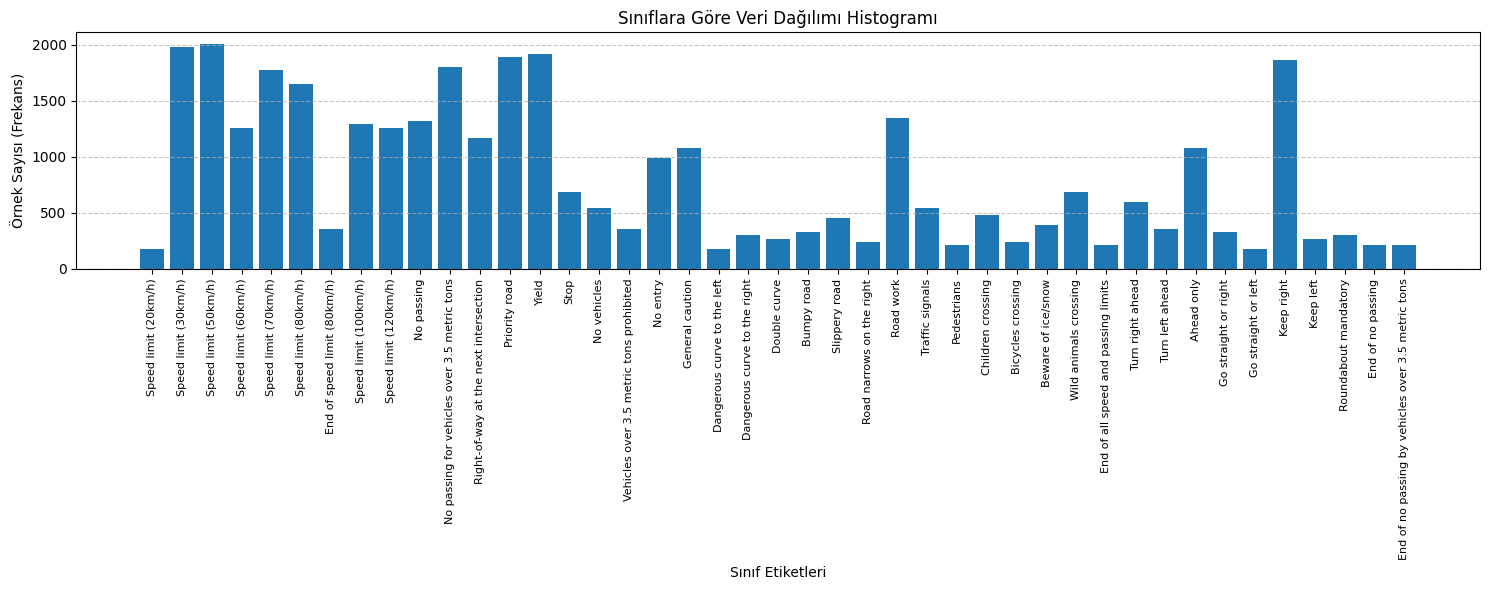

Eğitim Toplam Veri: 34799


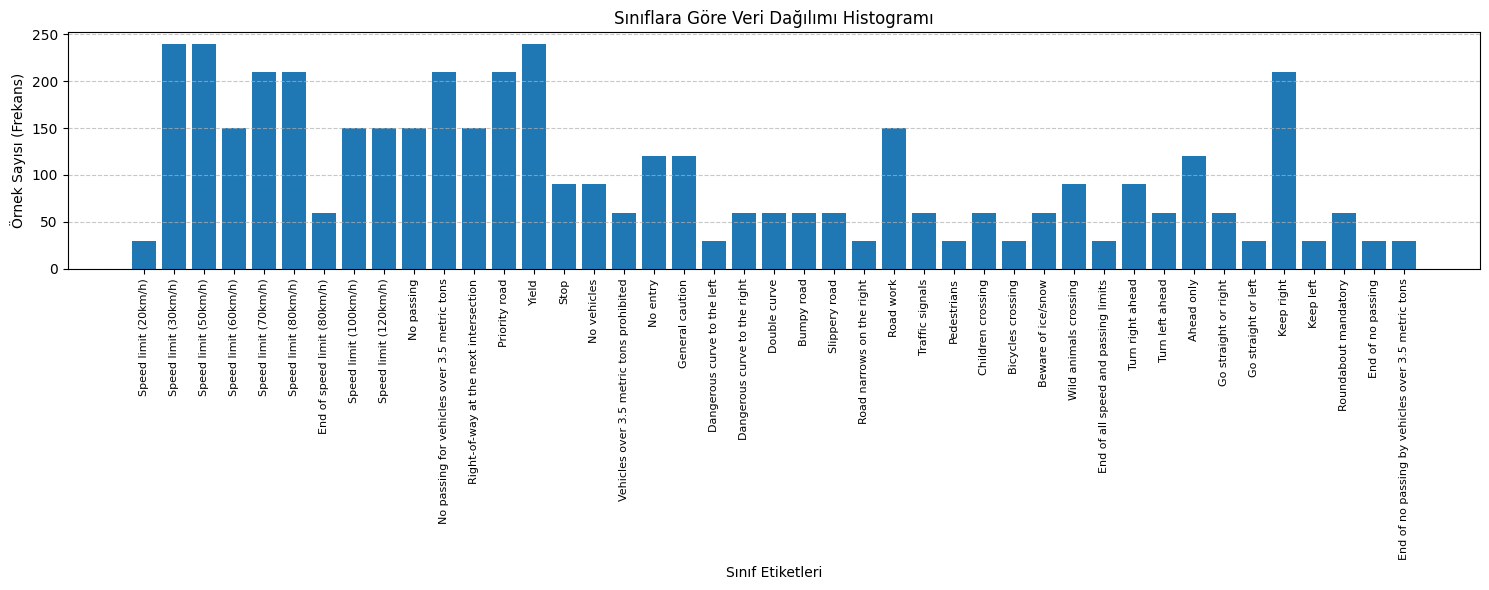

Validasyon Toplam Veri: 4410


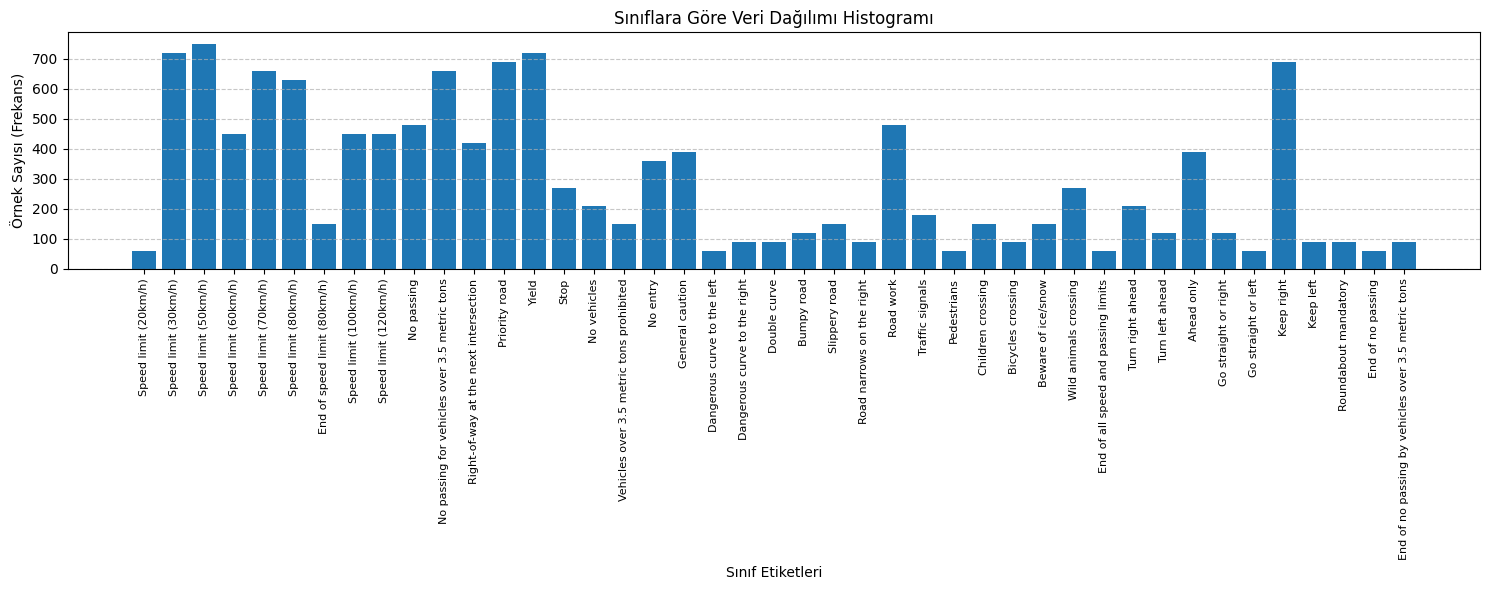

Test Toplam Veri: 12630


In [19]:
# Eğitim Veri Setinin Dağılım Haritası
y_train = train_set["labels"]
x_train = train_set["samples"]

t_classes,t_numbers = class_distribution_histogram_calculate(y_train)
class_distribution_histogram_show(t_classes,t_numbers)

print(f"Eğitim Toplam Veri: {y_train.shape[0]}")

y_valid = valid_set["labels"]
x_valid = valid_set["samples"]

classes,numbers = class_distribution_histogram_calculate(y_valid)
class_distribution_histogram_show(classes,numbers)

print(f"Validasyon Toplam Veri: {y_valid.shape[0]}")

y_test = test_set["labels"]
x_test = test_set["samples"]

classes,numbers = class_distribution_histogram_calculate(y_test)
class_distribution_histogram_show(classes,numbers)

print(f"Test Toplam Veri: {y_test.shape[0]}")


#### Eğitim Verilerinin Ağırlıklarının İncelenmesi

Bu kısımda ise, eğitim için verilerin eğitim sürecinde başarı oranına etki edebilecek veri ağırlıklarının hesaplanması gösterilmektedir. Ağırlıkların hesaplanmasının önemi ise, `Kayıp Fonksiyonlarında` düşük olan verilerin eğitiminin diğerine kıyasla daha iyi başarı oranı sağlamak istenmesidir.

Ağırlık hesaplamak için Toplam örnek sayısının, o sınıf için yer alan örnek sayısına bölünmesidir.

### Eğitim Verilerinin Parçalanması

Eğitim verilerinin tekrar parçalanmak istenmesinin sebebi ise düşük, orta ve yüksek yoğunlukta olan verilerin, model eğitimine olan katkısının incelenmesi olarak söylenebilir.

Bu verilerin sınıf başı 2000'den biraz fazla olan verileri aşağıdaki gibi oluşturulması sağlanmıştır;

* X1 veri seti: Bu veri seti, sınıf başı yaklaşık 800'den biraz fazla olan veriler ile düşük kapasitede nasıl bir başarı oranı sağlayacağı hedeflenmiştir. İlk eğitimin süresini kısaltması, başarıların ve kayıpların daha hızlı bir şekilde incelenmesini amaçlamıştır.

* X2 veri seti: Bu veri seti, sınıf başına 1200 veriden fazla olan bir veri setini göstermektedir. Bu veriler ise bir önceki veriden fazla örnek içermektedir. Bu veriler ikinci aşamada sağlayacağı başarı ve kayıp oranlarının incelenmesinde katkı sağlaması amaçlanmaktadır.

---

Bu verilerin dağılabilmesi için `sklearn` kütüphanesinin `model_selection` modülü yardımıyla `train_test_split` fonksiyonu kullanılarak uygulanmıştır. Bu fonksiyon parametreleri kısaca aşağıda anlatılmıştır.

* **`arrays` (Diziler)**

  * **Anlamı:** Aynı uzunlukta veya ilk boyutu (`shape[0]`) aynı olan dizinlenebilir (indexlenebilir) nesneler dizisini belirtir.
  
* **`train_size` (Test Boyutu)**

  * **Anlamı:** Veri kümesinin ne kadarının eğitim seti olarak ayrılacağını belirten parametredir.
  


* **`random_state` (Rastgele Durum)**

  * **Anlamı:** Veri ayırma işleminden önce verilere uygulanan karıştırmayı kontrol eder.

* **`shuffle` (Karıştırma)**

  * **Anlamı:** Veri ayırma işleminden önce verilerin karıştırılıp karıştırılmayacağını belirten bir mantıksal (boolean) parametredir.
  
* **`stratify` (Tabakalama)**

  * **Anlamı:** Veri ayırma işleminin, belirtilen sınıf etiketlerine göre **katmanlı** (stratified) bir şekilde yapılmasını sağlar. Bu, hem eğitim hem de test setlerinin orijinal veri kümesindeki sınıf oranlarını koruması için kritik öneme sahiptir.
  * **Örnek:** Eğer veri setinizde %80 "pozitif" ve %20 "negatif" etiketli örnekler varsa ve `stratify=y_etiketleri` kullanırsanız, eğitim ve test setleriniz de bu %80-%20 oranını korur. Bu, özellikle dengesiz (imbalanced) veri kümeleriyle çalışırken çok önemlidir.

Çıkacak olan veriler ise bir `Tuple` verisi olacaktır ve 4 adet veri çıkışı sağlayacaktır. Bu veriler ise `(X1,X2,Y1,Y2)` şeklinde olacaktır.



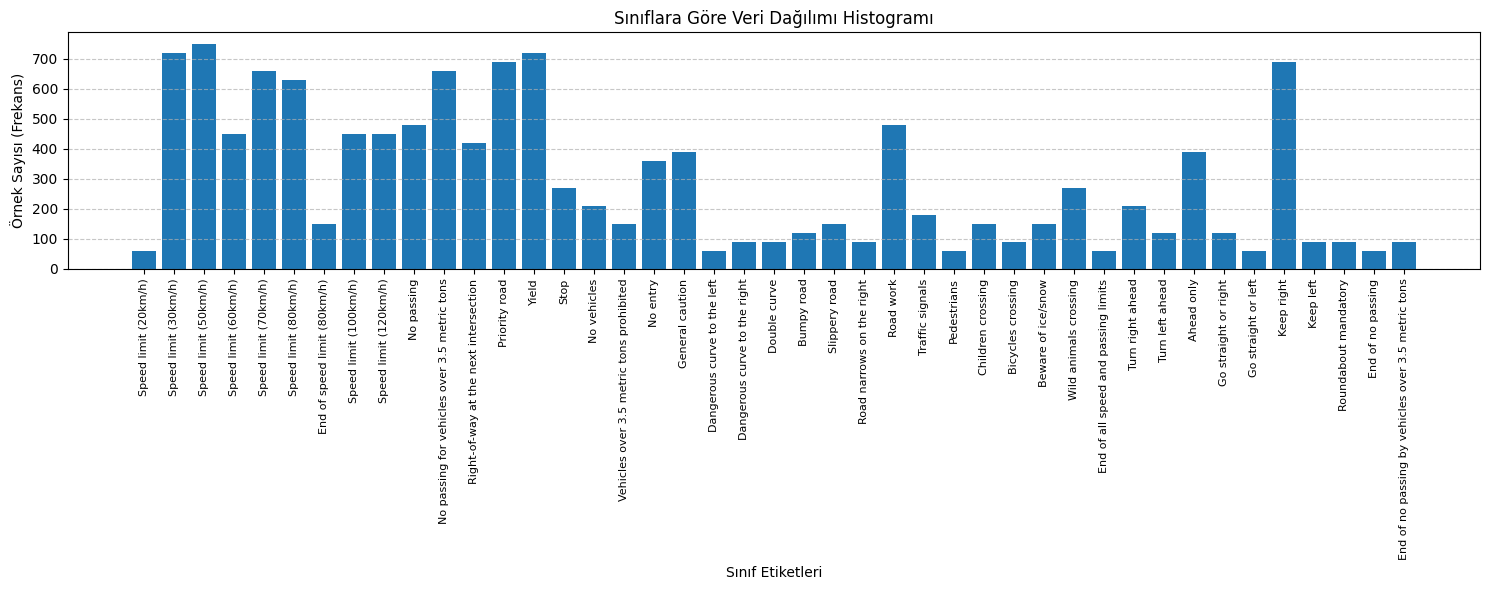

Y1 Toplam Veri: 17399, Ağırlıklar: tensor([193.3222,  17.5747,  17.3124,  27.6175,  19.6599,  21.0897,  96.6611,
         26.9752,  27.6175,  26.3621,  19.3322,  29.7419,  18.4116,  18.1240,
         50.4319,  64.4407,  96.6611,  35.1495,  32.2204, 193.3222, 115.9933,
        128.8815, 105.4485,  77.3289, 144.9917,  25.7763,  64.4407, 165.7048,
         72.4958, 144.9917,  89.2256,  50.4319, 165.7048,  58.1906,  96.6611,
         32.2204, 105.4485, 193.3222,  18.7086, 128.8815, 115.9933, 165.7048,
        165.7048])


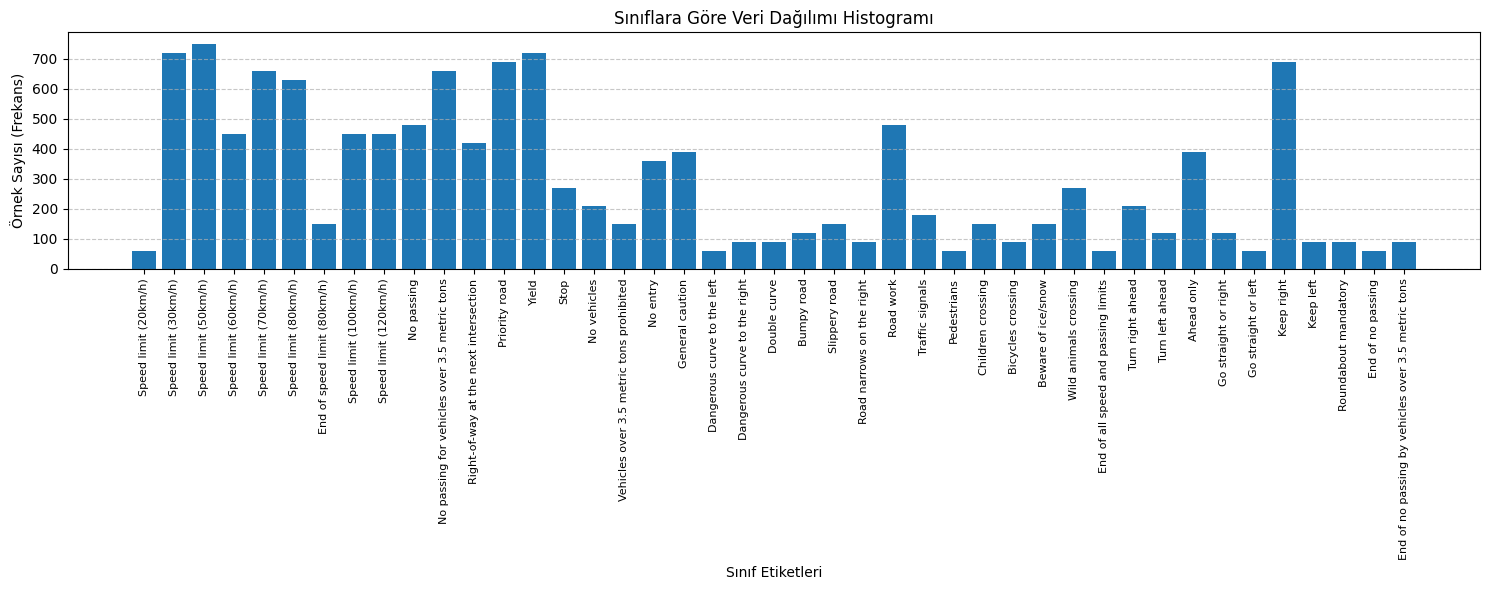

Y2 Toplam Veri: 17400, Ağırlıklar: tensor([193.3333,  17.5758,  17.3134,  27.6190,  19.6610,  21.0909,  96.6667,
         26.9767,  27.6190,  26.3636,  19.3333,  29.7436,  18.4127,  18.1250,
         50.4348,  64.4444,  96.6667,  35.1515,  32.2222, 193.3333, 116.0000,
        128.8889, 105.4545,  77.3333, 145.0000,  25.7778,  64.4444, 165.7143,
         72.5000, 145.0000,  89.2308,  50.4348, 165.7143,  58.0000,  96.6667,
         32.2222, 105.4545, 193.3333,  18.7097, 128.8889, 116.0000, 165.7143,
        165.7143])


In [20]:
# Veri setinin parçalanması.

import torch
from typing import Tuple
from sklearn.model_selection import train_test_split

X1_train,X2_train,Y1_train,Y2_train = train_test_split(x_train,y_train,shuffle=True,train_size=0.5,random_state=42,stratify=train_set["labels"]) # toplam verinin %40'si ilk %60 kısmı 2. eğitim.

# Veri setinin dağılım histogram grafiğinin incelenmesi.
t1_classes,t1_numbers = class_distribution_histogram_calculate(Y1_train)
class_distribution_histogram_show(classes,numbers)

t1_class_weights = []
for i in range(len(t1_classes)):
    class_weight = sum(t1_numbers) / t1_numbers[i]
    t1_class_weights.append(class_weight)
t1_class_weights = torch.Tensor(t1_class_weights)
print(f"Y1 Toplam Veri: {Y1_train.shape[0]}, Ağırlıklar: {t1_class_weights}")

t2_classes,t2_numbers = class_distribution_histogram_calculate(Y2_train)
class_distribution_histogram_show(classes,numbers)

t2_class_weights = []
for i in range(len(t2_classes)):
    class_weight = sum(t2_numbers) / t2_numbers[i]
    t2_class_weights.append(class_weight)
t2_class_weights = torch.Tensor(t2_class_weights)
print(f"Y2 Toplam Veri: {Y2_train.shape[0]}, Ağırlıklar: {t2_class_weights}")



## Verilerin Önişlemesi

Bu kısımda, verilerin önişlemesi ve bu fonksiyonların tanımları anlatılacak ve işlenecektir.

Veriler, piksel boyutları olarak 8 bayt olarak oluşturulan 0-255 değerleri arasında olan verileri temsil etmektedir. Bu pikseller aynı zamanda kırmızı, yeşil ve mavi renkleri oluşturan 3 veri barındıran tanımı içerir. Giriş verisi olarak önceden de belirtilen (C,H,W) şekliyle veriler giriş yapacak ve gerekli işlemler yapılacaktır.



### Verilerin Artırımı (Data Augmentation)

Verilerin artırımı yapılmasının önemi ise, modelin standart veriler ile aşırı öğrenme (overfitting) yapmaması veya düşük sayıdaki verilerin sayılarının arttırılmasını amaçlamaktadır. Veri artırımı, eğitim süreci için önemli bir aşamadır. Yapılması dahilinde aşırı öğrenme varsa tespit edilebilir ve model katmanları olması gerektiği gibi ayarlanarak iyi bir eğitim yapılabilir.


Bu verileri giriş verisi şeklinden standart bir görsel olarak dönüştürülmesi gerekmektedir. Bu verileri `ToPILImage` ile (C,H,W) formatından standart görsel formatı olan (H,W,C) şekline dönüştürülmesi gerekir. Bu veriler `numpy.ndarray` olarak alamayacağı için `Tensor` dönüşümü yapılması gerekmektedir. Bu dönüşüm `Dataset` aşamasında işlenecektir.  

Veri artırımı aşamaları ise aşağıdaki gibi belirtilmiştir.

* Röndürme(Rotation): Bu verileri belirtilen dereceye kadar döndürülmesi sonucu oluşturulacak olan yeni veriyi içermektedir.
* Yatay Çevirme (RandomHorizontalFlip): Görselin yatayda ayna görünümü ile yeni bir veri yaratılmasını amaçlar.
* Renk Titremesi (ColorJitter): Görselin belirtilen ayarlar ile yeni bir veri yaratılmasını amaçlar.
* Kırpma (RandomResizedCrop): Görselin belirtilen boyutlarda oluşturulacak şekilde küçültme ya da büyültme olarak düşünülebilecek şekilde boyutlanarak yeni bir veri oluşturulmasını sağlar.







### Normalizasyon

Normalize aşaması, eğitimin süresini kısaltmasını sağlayan en temel aşamadır. Bu kısımda, `0-255` arası değerleri alacak olan piksel değerlerini `0-1` arasına dönüşümünü sağlamak, normalize olarak gösterilir. `ToTensor` ise, bu dönüşümü bahsedildiği gibi yapmaktadır.

`Normalize` aşaması ise, veri setinin başarı oranına iyi anlamda etkilemesi için `0-1` aralığında olan normalize verilerileri `-1-0` aralığına dönüştürmektedir. Bu dönüşüm için gereken iki parametre vardır. Bu parametreler `ortalama (mean)` ve `standart sapma(std)` şeklinde gösterilir. Bu parametreler, standart olarak `0.5` şeklinde girilmesinin önemi çok basit bir hesaplamada gösterilir. Bu hesaplama kısaca aşağıda anlatılmaktadır.

    cikis = (giris - ortalama) ÷ standart sapma


Örnek vermek gerekirse;

    = (1 - 0.5 ) ÷ 0.5  -> 1 olacaktır.

    = (0 - 0.5 ) ÷ 0.5  -> -1 olacaktır.

### Veri Artırımı ve Normalize Etme Aşaması

Bu kod kısmında, verilerin nasıl artırıldığı, nasıl normalize edildiğini gösteren kod bloğu aşağıda gösterilmiştir.

#### Normalizasyon için Ortalama ve Standart Sapma Hesapları



##### Fonksiyon Tanımı

Bu fonksiyonda, giriş için vereceğimiz (N,C,H,W) boyutlarında verilen verilerin, öncelikle ortalamaları ve standart sapmaları hesaplanmalıdır. Bu fonksiyonda kısaca verinin 4. boyuttan farklı olmadığı doğrulandıktan sonra `numpy` kütüphanesinin `mean` ve `std` fonksiyonları ile kolayca hesaplanabilir. Dikkat edilmesi gereken tek bir nokta ise, transform içerisinde normalize edilmeden önce 0-255 aralığında olan veriler, 0-1 aralığına indirgendiği için hesaplamadan önce aynı verileri verebilmemiz gerekmektedir.

In [21]:
import numpy as np
import torch
from typing import Tuple
from tqdm import tqdm

def calculate_mean_std_from_numpy(data_array: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    (N, C, H, W) formatındaki NumPy dizisi için kanal bazında ortalama (mean) ve
    standart sapma (std) değerlerini hesaplar ve PyTorch tensorü olarak döndürür.

    Args:
        data_array (np.ndarray): Hesaplama yapılacak tüm görüntüleri içeren NumPy dizisi.
                                 Format: (Görüntü Sayısı, Kanal, Yükseklik, Genişlik)

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: Mean ve Std değerlerini içeren PyTorch tensorleri.
    """

    # Veri setinin boyutlarını al (N, C, H, W)
    if data_array.ndim != 4:
        raise ValueError(f"Giriş dizisi 4 boyutlu olmalıdır (N, C, H, W). Gelen boyut: {data_array.ndim}")

    N, C, H, W = data_array.shape

    print(f"--- {N} Görüntü, {C} Kanal İçin Mean ve Std Hesaplama Başladı ---")

    # 1. Ortalama Hesaplama (Mean)

    # Kanal bazında ortalama hesaplamak için tüm N, H ve W eksenlerinde ortalama alınır.
    # np.mean(..., axis=(0, 2, 3)) işlemi, N, H ve W eksenlerini birleştirir ve
    # C eksenine ait (kanal) değerleri döndürür. Çıktı boyutu (C) olacaktır.

    # Hesaplama
    channels_mean = np.mean(data_array, axis=(0, 2, 3))

    # 2. Standart Sapma Hesaplama (Std)

    # Kanal bazında standart sapma hesaplanır.
    channels_std = np.std(data_array, axis=(0, 2, 3))

    # 3. PyTorch Tensor Çıkışı
    mean_tensor = torch.tensor(channels_mean, dtype=torch.float32)
    std_tensor = torch.tensor(channels_std, dtype=torch.float32)

    # 3 ondalık basamak
    mean_tensor = torch.round(mean_tensor * 1000) / 1000
    std_tensor  = torch.round(std_tensor * 1000) / 1000

    # Bilgi Çıktısı
    print("\n--- Hesaplama Tamamlandı ---")
    print(f"Hesaplanan Ortalama (Mean) Değerleri: {mean_tensor.tolist()}")
    print(f"Hesaplanan Standart Sapma (Std) Değerleri: {std_tensor.tolist()}")

    return mean_tensor, std_tensor

##### Ortalama ve Standart Sapmaların Hesaplanması

Bu aşamada ise, girilecek olan verilerin önce 0-1 aralığına indirgenmiş olması gerekmektedir. Transform içerisinde gerçekleşecek olan senaryo gereği, normalize aşamasından önce bu işlem gerçekleştiği için ham veri ile beslemenin, ortalama ve standart sapmalarda aşırı sapmaya sebep olabileceği bilinmektedir.

In [22]:
means = []
stds = []
print(X1_train.shape)
calculated_mean, calculated_std = calculate_mean_std_from_numpy(X1_train.transpose(0,3,1,2)/255)
means.append(calculated_mean)
stds.append(calculated_std)

calculated_mean, calculated_std = calculate_mean_std_from_numpy(X2_train.transpose(0,3,1,2)/255)
means.append(calculated_mean)
stds.append(calculated_std)

calculated_mean, calculated_std = calculate_mean_std_from_numpy(x_test.transpose(0,3,1,2)/255)
means.append(calculated_mean)
stds.append(calculated_std)

calculated_mean, calculated_std = calculate_mean_std_from_numpy(x_valid.transpose(0,3,1,2)/255)
means.append(calculated_mean)
stds.append(calculated_std)

(17399, 32, 32, 3)
--- 17399 Görüntü, 3 Kanal İçin Mean ve Std Hesaplama Başladı ---

--- Hesaplama Tamamlandı ---
Hesaplanan Ortalama (Mean) Değerleri: [0.33899998664855957, 0.3109999895095825, 0.32100000977516174]
Hesaplanan Standart Sapma (Std) Değerleri: [0.2709999978542328, 0.2590000033378601, 0.26499998569488525]
--- 17400 Görüntü, 3 Kanal İçin Mean ve Std Hesaplama Başladı ---

--- Hesaplama Tamamlandı ---
Hesaplanan Ortalama (Mean) Değerleri: [0.3409999907016754, 0.31200000643730164, 0.32100000977516174]
Hesaplanan Standart Sapma (Std) Değerleri: [0.2720000147819519, 0.25999999046325684, 0.26600000262260437]
--- 12630 Görüntü, 3 Kanal İçin Mean ve Std Hesaplama Başladı ---

--- Hesaplama Tamamlandı ---
Hesaplanan Ortalama (Mean) Değerleri: [0.3370000123977661, 0.3089999854564667, 0.3199999928474426]
Hesaplanan Standart Sapma (Std) Değerleri: [0.2720000147819519, 0.2630000114440918, 0.27300000190734863]
--- 4410 Görüntü, 3 Kanal İçin Mean ve Std Hesaplama Başladı ---

--- Hesapl

#### Transformların Derlenmesi

Bu aşamada verilerin, eğitime en hazır hale getirileceği aşamaya getirilecektir. Bu aşama, verilerin artırımı ve normalizasyonlar gibi eklenmesini istediğimiz aşamaları kapsamaktadır.

In [23]:
# Verilerin Artırımı ve Normalizasyon işlemleri
from torchvision import transforms

# Ortalama (Mean)
NORMALIZE_MEAN = [0.3390, 0.3110, 0.3210] 
# (Ortalama olarak 17399 ve 17400'deki en büyük kümeyi kullanıyoruz)

# Standart Sapma (Std)
NORMALIZE_STD  = [0.2710, 0.2590, 0.2650] 
# (Ortalama olarak 17399 ve 17400'deki en büyük kümeyi kullanıyoruz)


train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(20), # görüntüyü ±10° çevirerek farklı varyasyonlar yaratır.
    transforms.RandomVerticalFlip(), # görüntüyü yatayda çevirir.
    transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1,hue=0.1), # görüntünün parlaklık, kontrast, satürasyon ve hue değerlerini ayarlar.
    transforms.RandomResizedCrop(32,scale=(0.8,1.0)), #görüntü, 0.8 ile 1.0 arasında küçültülür, 32x32 olarak oranlanır.
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN,NORMALIZE_STD)
])
# TEST SET İSTATİSTİKLERİ (12630 Görüntü)

TEST_MEAN = [0.3410, 0.3120, 0.3210]
TEST_STD  = [0.2720, 0.2600, 0.2660]
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(TEST_MEAN,TEST_STD)
])

# VALID SET İSTATİSTİKLERİ (4410 Görüntü)

VAL_MEAN = [0.3370, 0.3090, 0.3200]
VAL_STD  = [0.2720, 0.2630, 0.2730]
validation_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(VAL_MEAN,VAL_STD)
])

## Dataset Sınıfının Oluşturulması ve Dataset Tanımları

Dataset sınıfı tanımlaması, eğitim için bir sonraki aşama olarak söylenebilir. X ve Y verilerini gerekli dönüşümler ve transform işlemleri için gerekli olan bir aşamadır. Bu kısımda `SampleDataset` sınıfını oluşturmayı ve verileri bu sınıf ile dataset verilerine dönüştürülmesi amaçlanmaktadır.



### SampleDataset Sınıfı

Bu sınıfın tanımlaması için temel 3 fonksiyonu oluşturmak ve 3 adet parametrenin girilmesi gerekmektedir. Bu sınıfa girilecek parametreler aşağıdaki gibi olmalıdır.

* x_array: Bu veri, `numpy.ndarray` tipinde olan bir listeyi içermektedir. X verileri, verinin tanımı gereki (N,H,W,C) şeklinde olması, transform parametresi için önemli bir husustur. Bu bir görsel veridir ve PIL image için gerekli transform hesaplamaları daha sonra yönetilecektir.

* y_array: Bu veri, sınıfın numaralarını içeren `numpy.ndarray` verisini içeren listeyi göstermektedir. İçerdiği örnek sayısı, X ve Y verilerinin eşit olması gerekmektedir.

* transform: Bu veri, veri artırımı ve normalizasyon işlemlerini içeren tanımı göstermektedir. Her bir tekil `Tensor` için uygulaması gerekmektedir.


Bu parametreler ile tamamlanması gereken 3 adet temel fonksiyon yer almaktadır. Bu fonksiyon tanımları aşağıdaki gibidir.

* \__init__ : Bu veri, standart bir sınıf tanımı içermektedir. Parametreler burada giriş olarak verilir. burada sınıf içerisine değişken olarak atanır.

* \__len__ : Bu fonksiyon toplam veri sayısını döndürür.

* \__getitem__: Bu fonksiyon, istenilen numarada veri ile tekil x ve y verileri alınır, x verisi tensor dönüşümü yapılır ve eğer varsa transform dönüşümü yapılarak örnek ve sınıfı şeklinde geri döndürülür. Temelde tensor dönüşümü sağlanır ve veri artırımı gibi operasyonlar ile veri işlenmiş şekilde döndürülür.

In [24]:
from torch.utils.data import Dataset

class SampleDataset(Dataset):
    def __init__(self,x_val:np.ndarray,y_val:np.ndarray,transform:transforms.Compose=None):
        self.x_val = x_val
        self.y_val = y_val
        self.transform = transform

    def __len__(self):
        return len(self.y_val)
        
    # index ile verinin alınması ve transform aşamalarını yürütülmesi.
    def __getitem__(self,idx):
        sample = self.x_val[idx]
        label = self.y_val[idx]
        sample = sample.transpose(2,0,1) # (H,W,C) -> (C,H,W)
        sample = torch.from_numpy(sample)
        if self.transform:
            sample = self.transform(sample)
        return sample,label



### Dataset Tanımlanması

Belirtildiği gibi 3 parametreye ihtiyaç duran `SampleDataset` verisi, X,Y ve transform değerleri ile kolay bir şekilde yaratılabilir ve değişkenlere hazırlanabilir. Örnek aşağıda yer almaktadır.

In [25]:
train1_dataset = SampleDataset(X1_train, Y1_train,transform= train_transform)
train2_dataset = SampleDataset(X2_train, Y2_train,transform= train_transform)


test_dataset = SampleDataset(x_test ,y_test,transform=test_transform)
validation_dataset= SampleDataset(x_valid,y_valid,transform=validation_transform)



## Modelin Açıklanması

Verdiğimiz PyTorch sınıfı, trafik işareti sınıflandırması için özelleştirilmiş bir Evrişimli Sinir Ağı (CNN) modelini tanımlıyor. Model, görüntüleri işlemek için evrişim, aktivasyon ve havuzlama katmanlarından oluşan bir `özellik çıkarıcı (feature extractor)` bölümü ve ardından sınıflandırma yapmak için tam bağlı katmanlardan oluşan bir `sınıflandırıcı (classifier)` bölümü olmak üzere iki ana kısımdan oluşur.

Modelin mimarisi, dışarıdan alınan parametrelerle dinamik olarak inşa edilir, bu da hiperparametre ayarlaması için esneklik sağlar.




### Özellik Çıkarıcı (Feature Extractor) Katmanları

Bu kısım, giriş görüntülerinden anlamlı özellikleri çıkarmak için tasarlanmıştır. `features` adlı `nn.Sequential` bloğu içinde yer alır.

* **Evrişim (Convolutional) Katmanlar (`nn.Conv2d`):** Görüntüdeki kenar, doku gibi detayları tespit etmek için kullanılır. Model, `num_layers` parametresine göre birden fazla evrişim katmanı oluşturur. Her bir katmanın çıktı filtre sayısı, önceki katmanın iki katına çıkarılır (`32`, `64`, `128`...). Bu, modelin daha derin katmanlarda daha karmaşık ve soyut özellikleri öğrenmesini sağlar.
* **ReLU Aktivasyon Fonksiyonu (`nn.ReLU`):** Her evrişim katmanından sonra uygulanır. Negatif değerleri sıfıra dönüştürerek modele doğrusal olmayan bir özellik katar ve öğrenme hızını artırır.
* **Maksimum Havuzlama (Max Pooling) Katmanları (`nn.MaxPool2d`):** Her evrişim ve aktivasyon katmanından sonra gelir. Görüntü boyutunu yarıya indirerek, hem işlem yükünü azaltır hem de modelin konumdan bağımsız özellikleri öğrenmesine yardımcı olur.



### Sınıflandırıcı (Classifier) Katmanları

Özellik çıkarıcıdan çıkan boyutlar, sınıflandırma için düzleştirilir ve tam bağlı katmanlara beslenir. Bu kısım, `classifier` adlı `nn.Sequential` bloğu içinde yer alır.

* **Düzleştirme (`nn.Flatten`):** Evrişimli katmanların 3 boyutlu çıktısını (yükseklik, genişlik, kanal), tam bağlı katmanlara beslenebilmesi için tek boyutlu bir vektöre dönüştürür.
* **Dropout (`nn.Dropout`):** Eğer `dropout_size` parametresi sıfır değilse, katman aralarına eklenir. Bu, eğitim sırasında rastgele nöronları devre dışı bırakarak modelin aşırı öğrenmesini (overfitting) engeller ve genelleme yeteneğini artırır.
* **Tam Bağlı (Linear) Katmanlar (`nn.Linear`):** Bu katmanlar, düzleştirilmiş özellik vektörünü alır ve sınıflandırma kararı vermek için birleştirir. `dense_layer_size` parametresine göre birden fazla tam bağlı katman oluşturulabilir. Her bir katmanın nöron sayısı dinamik olarak azalır, bu da ağın daha kompakt hale gelmesini sağlar.
* **Çıkış Katmanı (`nn.Linear`):** Sınıflandırıcı bölümünün son katmanıdır. Girdiyi, modelin tahmin etmesi gereken sınıf sayısına (`num_classes`) eşit boyutta bir çıktı vektörüne dönüştürür. Bu çıktı, her bir sınıf için bir skor içerir.

Bu dinamik yapı, modelin farklı hiperparametre kombinasyonlarıyla kolayca test edilmesini sağlayarak en uygun model mimarisinin bulunmasına olanak tanır.

### Modelin Hazırlanması

Modelin hazırlanması için, kullandığımız `Pytorch` kütüphanesi ile `Module` oluşturulması gerekmektedir. Bu model sınıfı, parametreleri dinamik olarak alabilmekte ve katmanları hesaplamalar yaparak veri kaybı olmadan oluşturmaktadır.

Modelin oluşturulmasında bilinmesi gerekenler aşağıdaki gibidir.

* \__init__: Bu kısımda dışarıdan alacağımız verileri kullanarak gerekli parametre tanımlarını, bu parametrelerin gerektirdiği şekilde hesaplamalar yaparak ilk yapımız olan `Özellik Çıkarıcı` katmanını oluşturmamız gerekiyor.

  Bu katmanda temel hesaplamamız gereken parametreler aşağıda madde olarak verilmiştir.
    * Evrişim katmanı için girilecek olan filtre sayısı, iterasyon sayısı kadar 2 ile çarpılması gerekmektedir. Bu genişletme, parametrelerin tutarlı olması için gerekmektedir.
    * Kernel sayısının tek sayılar ile kullanılabilmesi gerekmektedir. Bu sayının ilişkili olduğu 2 şey ise `Padding` miktarı ve `Stride` miktarıdır. En temel hesaplama için formülü ise `Formül-1` içerisinde verilmiştir.
    * Katmanlar 3 boyuttan tek bir boyuta indirgendiğinde katman sayılarının çarpımı kadar boyut oluşturmaktadır. Bu boyut (128,4,4) için 2048 boyutunda olduğu bilgisini vermektedir. Her havuzlama algoritması sonrası katmanlar yarı yarıya düştüğü için filtre sayısı artmakta, yükseklik ve genişlik sayısı düşmektedir. Bu değer, belirlenen değerler altındaki verilerin umursanmaması, yani modelin aşırı öğrenmemesi için gereken katmandır.
    * Linear, yani Dense katmanı, giriş ve çıkış katmanları arasında indirgeme yapar. İstediğimiz şey ise sınıf sayısı kadar bir değer oluşturması ve bu değerlerin, 43 boyutlu listede kaç tane 1 varsa o sınıfı temsil eder gibi bir sonuç çıkartmasıdır.

    

* forward: Bu katmanda, girilen x tensor verisi öznitelik öıkarımı ve sınıflandırma katmanlarından geçerek istenilen çıkarımı yaptıracak olan fonksiyonu temsil eder.


---

**Formul-1**

$$O = \frac{I - K + 2P}{S} + 1$$

Bu formüldeki değişkenler şunlardır:

* $O$: Çıktı boyutu
* $I$: Giriş boyutu
* $K$: Filtre (kernel) boyutu
* $P$: Dolgu (padding)
* $S$: Adımlama (stride)

    

In [26]:
import torch
import torch.nn as nn
from typing import Dict

class TrafficSignCNN(nn.Module):
    def __init__(self, params: Dict, channel_size=3, num_classes=43, initial_size=32):
        super(TrafficSignCNN, self).__init__()

        # ------------------
        # Features (Conv part)
        # ------------------
        layers = []
        input_channels = channel_size
        current_size = initial_size
        kernel_size = params.get("kernel_size", 3)
        padding_size = (kernel_size - 1) // 2
        stride = 1

        num_filters = params.get("num_filters", 32)
        num_layers = params.get("num_layers", 2)

        for i in range(num_layers):
            out_channels = num_filters * (2**i) 
            layers.append(nn.Conv2d(input_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding_size))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2,2))
            input_channels = out_channels # giriş - çıkış boyutları eşitlenir.
            current_size = current_size // 2  # pooling sonrası boyut yarılandı

        self.features = nn.Sequential(*layers)

        # ------------------
        # Classifier (Dense part)
        # ------------------
        flattened_size = input_channels * current_size**2  # GAP sonrası

        dropout_size = params.get("dropout_size", 0.5)
        dense_node_size = params.get("dense_node_size", 128)
        dense_layer_size = params.get("dense_layer_size", 2)

        dense_layers = []
        for i in range(dense_layer_size):
            dense_layers.append(nn.Linear(flattened_size, dense_node_size))
            dense_layers.append(nn.ReLU())
            if dropout_size > 0:
                dense_layers.append(nn.Dropout(dropout_size))
            flattened_size = dense_node_size
            dense_node_size = max(flattened_size // 2, num_classes)  # çok küçük olmasın

        dense_layers.append(nn.Linear(flattened_size, num_classes))

        self.classifier = nn.Sequential(*dense_layers)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


## Eğitim Fonksiyonu Oluşturma

Bu kod bloğu, bir PyTorch modelini eğitmek ve doğrulama seti üzerinde performansını izlemek için tasarlanmış kapsamlı bir fonksiyondur. Fonksiyonun her bir bölümü, modelin öğrenme sürecini yönetmek için belirli bir amaca hizmet eder.

### Hazırlık ve Geçmiş Kaydı

Fonksiyon, eğitim döngüsü başlamadan önce modelinizi belirtilen cihaza (`device`) gönderir ve tüm eğitim metriklerini kaydetmek için **`history`** adında bir sözlük oluşturur. Bu sözlük, her epoch için eğitim ve doğrulama kayıp (`loss`) ve doğruluk (`accuracy`) değerlerini saklar.



#### Erken Durdurma Tetikleyicisi

Bu aşamada ise, belirtilen `Epoch` kadar yapacağı eğitimi belirteceğimiz her aşamada test edecektir. Ezberleme durumuna geldiğini, doğrulama verilerindeki dalgalanmaları test edecek, belirtilen eşikten fazla ise fazla öğrenme durumuna girmesini engelleyecektir.

In [27]:
import numpy as np
import torch

class EarlyStopper:
    """Validation Loss'un iyileşmediği takdirde eğitimi durdurur."""
    def __init__(self, patience=10, min_delta=0, path='best_model.pt'):
        """
        Args:
            patience (int): Kaybın iyileşmediği ardışık epoch sayısı.
            min_delta (float): Yeni kaybın eskisinden en az ne kadar iyi olması gerektiği.
            path (str): En iyi modelin kaydedileceği dosya yolu.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path
        
    def __call__(self, val_loss, model):
        """Val Loss'u kontrol eder ve gerekiyorsa modeli kaydeder."""
        if self.best_loss is None:
            # İlk epoch
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            # Kayıp iyileşmedi (veya iyileşme yeterli değil)
            self.counter += 1
            print(f"EarlyStop Counter: {self.counter} / {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # Kayıp iyileşti! (Daha düşük bir loss bulduk)
            print(f"Validation Loss iyileşti ({self.best_loss:.4f} --> {val_loss:.4f}). Model kaydediliyor.")
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0 # Sayacı sıfırla

    def save_checkpoint(self, val_loss, model):
        """Modelin ağırlıklarını kaydeder."""
        torch.save(model.state_dict(), self.path)

### Eğitim (Train) Döngüsü

Bu döngü, modelin ağırlıklarını optimize etmek için kullanılır.

* **`model.train()`**: Modeli **eğitim moduna** alır. Bu, Dropout ve BatchNorm katmanları gibi eğitim sürecine özgü davranışları etkinleştirir.
* **Döngü İçinde Batch İşleme**: `tqdm` ile süreci görselleştiren bir döngü, her bir veri `batch`'ini işler.
    * **Veri Yükleme**: Giriş verileri ve etiketleri (`inputs`, `labels`) belirlenen cihaza (`device`) taşınır.
    * **Gradyanları Sıfırlama**: `optimizer.zero_grad()` komutu, bir önceki döngüden kalan gradyanları temizler.
    * **İleri Yayılım (Forward Pass)**: `outputs = model(inputs)` ile modelin tahminleri alınır.
    * **Kayıp Hesaplama**: `loss = criterion(outputs, labels)` ile modelin tahminlerinin ne kadar yanlış olduğu ölçülür.
    * **Geriye Yayılım (Backward Pass)**: `loss.backward()` ile gradyanlar hesaplanır. Bu, modelin hangi yönde ve ne kadar değişmesi gerektiğini belirler.
    * **Ağırlık Güncelleme**: `optimizer.step()` ile modelin ağırlıkları gradyanlara göre güncellenir.
* **Epoch Sonu Metrikleri**: Döngü sonunda, o epoch'un ortalama eğitim kaybı ve doğruluğu hesaplanır ve `history` sözlüğüne eklenir.

### Doğrulama (Validation) Döngüsü

Bu döngü, modelin eğitim verisinde ezberlediği bilginin ne kadarını yeni verilere genellediğini ölçer.

* **`model.eval()`**: Modeli **değerlendirme moduna** alır. Dropout ve BatchNorm gibi katmanlar devre dışı bırakılır veya sabitlenir, böylece tutarlı sonuçlar elde edilir.
* **`torch.no_grad()`**: Bu blok içinde gradyan hesaplaması devre dışı bırakılır. Bu, bellekten tasarruf sağlar ve hesaplama süresini kısaltır çünkü bu aşamada ağırlıklar güncellenmez.
* **Tahmin ve Metrikler**: Modelin her bir doğrulama `batch`'i için tahminleri alınır ve bu tahminler ile gerçek etiketler karşılaştırılarak kayıp ve doğruluk değerleri hesaplanır.
* **Sonuçları Saklama**: O epoch'a ait doğrulama kaybı ve doğruluğu, `history` sözlüğüne eklenir. Ayrıca, daha sonra Precision, Recall gibi detaylı metrikleri hesaplamak için tahmin (`prediction_list`) ve gerçek etiketler (`label_list`) ayrı listelerde saklanır.

### Raporlama ve Dönüş Değeri

Her epoch'un sonunda, hem eğitim hem de doğrulama aşamalarının sonuçları ekrana basılır. Bu, modelin ilerlemesini anlık olarak takip etmeyi kolaylaştırır. Fonksiyon, tüm metrikleri içeren `history` sözlüğünü döndürür. Bu sözlük, daha sonra performans grafikleri çizmek veya raporlar oluşturmak için kullanılabilir.

In [28]:
from typing import Dict
import torch.optim as optim

def train_model(model: nn.Module, criterion, optimizer, num_epochs:int, t_dataloader, val_dataloader, device="cpu",is_scheduler=False,is_early_stop=False)->Dict[str,any]:
    model.to(device)

    history = {
        "num_epochs": num_epochs, # eğitim sayısı
        "train": {"loss": [], "accuracy": []}, # eğitimdeki kayıp ve başarı değerleri.
        "validation": {"loss": [], "accuracy": []}, # doğrulama kayıp ve başarı değerleri
        "test": {"prediction": [], "labels": []} # doğrulama verilerindeki y_pred ve y_label değerleri.
    }

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.5,patience=2,threshold=0.0001)        # LR düştüğünde bildirim gönderir)

    early_stopper = EarlyStopper(patience=5, min_delta=0.005) # 15 epoch bekle, 0.005'ten küçük düşüşü görmezden gel


    for epoch in range(num_epochs):
        # Eğitim (Train) Aşaması
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        loop = tqdm(t_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs} (Train)", leave=False)

        for inputs, labels in loop:
            # tensor aygıtları belirle.
            inputs = inputs.to(device)
            labels = labels.to(device)

            # gradyan sıfırla ve eğit, kayıpları hesapla
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # aşama atlat.
            loss.backward()
            optimizer.step()

            # kayıp, tahmin ve total hesaplar.
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_accuracy = 100 * correct_train / total_train

        history["train"]["loss"].append(epoch_train_loss)
        history["train"]["accuracy"].append(epoch_train_accuracy)

        # Doğrulama (Validation) Aşaması
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0

        prediction_list = []
        label_list = []

        with torch.no_grad(): # gradyanlar devre dışı
            for inputs, labels in val_dataloader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

                prediction_list.extend(predicted.tolist())
                label_list.extend(labels.tolist())

        # eğtiim aşırı öğreniyorsa, lr değerini düşürür.
        if is_scheduler:
          scheduler.step(val_loss)

        epoch_val_loss = val_loss / total_val
        epoch_val_accuracy = 100 * correct_val / total_val

        print(f"Epoch {epoch + 1:<3} - Train Loss: {epoch_train_loss:^10.4f} Train Accuracy: {epoch_train_accuracy:^3.2f}% | Validation Loss: {epoch_val_loss:^10.4f} Validation Accuracy: {epoch_val_accuracy:^3.2f}%  |  lr: {scheduler.get_last_lr()}")

        
        history["validation"]["loss"].append(epoch_val_loss)
        history["validation"]["accuracy"].append(epoch_val_accuracy)
        history["test"]["prediction"].append(prediction_list)
        history["test"]["labels"].append(label_list)
        
        current_lr = optimizer.param_groups[0]['lr']
        if current_lr < 1e-6:
            print("Öğrenme oranı çok düştü, eğitim durduruluyor.")
            break
        if is_early_stop:
            early_stopper(val_loss, model)
    
        if early_stopper.early_stop:
            print("Erken Durdurma tetiklendi!")
            break

    return history

## Metrik Hesaplama ve Grafik Oluşturma Fonksiyonları Oluşturması.

### Grad-CAM Tanımlaması

Grad-CAM (Gradient-weighted Class Activation Mapping), bir Evrişimli Sinir Ağının (CNN) bir görüntü üzerinde tahmin yaparken görüntünün hangi bölgelerine odaklandığını gösteren güçlü bir görselleştirme tekniğidir. Modelin kararlarını daha şeffaf hale getirerek, neyin doğru neyin yanlış gittiğini anlamamıza yardımcı olur.





#### Grad-CAM Sınıf Tanımlaması

Grad-CAM algoritmasını PyTorch'ta uygulamak için, modelin ileri yayılımını (`forward pass`) ve geri yayılımını (`backward pass`) izlememiz gerekir. Bu işlem, genellikle **hook** adı verilen mekanizmalarla yapılır. `GradCAM` sınıfı, bu mantığı düzenli ve tekrar kullanılabilir bir şekilde kapsüller.

Bu sınıf, `__init__` metodunda model ve hedef katmanın adını alır ve **Python hook mekanizmasını** kullanarak o katmanın çıktılarını ve gradyanlarını kaydeder. `__call__` metodu ise girdi olarak aldığı görüntü tensoru için ileri ve geri yayılımı gerçekleştirir, gradyanları ve aktivasyonları birleştirerek Grad-CAM ısı haritasını hesaplar.

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt



class GradCAM:
    def __init__(self, model:nn.Module, target_layer_name):
        self.model = model
        self.model.eval() # modeli validation moduna alor.
        self.target_layer_name = target_layer_name
        self.activations = None
        self.gradients = None

        # Hook'ları kaydet
        for name, module in self.model.named_modules():
            if name == self.target_layer_name:
                module.register_forward_hook(self._save_activations)
                module.register_backward_hook(self._save_gradients)
    #Aktivasyon ve gradiyenleri kaydet.
    def _save_activations(self, module, input, output):
        self.activations = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, target_class=None):
        self.model.zero_grad() #gradyanları durdur.

        # İleri yayılım (Forward pass)
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax().item()

        # Geri yayılım (Backward pass)
        one_hot_output = torch.zeros_like(output)
        one_hot_output[0][target_class] = 1 # İlk örnek için

        output.backward(gradient=one_hot_output, retain_graph=True) # `retain_graph=True` model eğitimi sırasında gerekebilir

        # Gradyanları ortalama ve aktivasyonlarla çarpma
        pooled_gradients = torch.mean(self.gradients, dim=[2, 3])

        # Isı haritasını oluşturma
        # Aktivasyonların boyutları: (batch_size, channels, H, W)
        # pooled_gradients boyutları: (batch_size, channels)

        # pooled_gradients'ı aktivasyon boyutuna genişletme
        # (batch_size, channels, 1, 1) -> (batch_size, channels, H, W)
        for i in range(pooled_gradients.size(0)):
            for j in range(pooled_gradients.size(1)):
                self.activations[i, j, :, :] *= pooled_gradients[i, j]

        heatmap = torch.sum(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)

        # Isı haritasını giriş görüntüsü boyutuna yeniden ölçekleme
        heatmap = F.interpolate(heatmap.unsqueeze(0).unsqueeze(0),
                                size=(input_tensor.shape[2], input_tensor.shape[3]),
                                mode='bilinear',
                                align_corners=False).squeeze()

        # Normalizasyon
        heatmap = heatmap.detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0) # Sadece pozitif gradyanlar
        if np.max(heatmap) > 0:
            heatmap /= np.max(heatmap)

        return heatmap



#### Grad-CAM Grafiği Oluşturma

Hesaplanan ısı haritasını, orijinal görüntünün üzerine bindirerek anlamlı bir görselleştirme elde edebiliriz. Bu işlem, genellikle `OpenCV` gibi kütüphanelerle gerçekleştirilir.

In [30]:
def show_cam_on_image(img, heatmap):
    """
    Orijinal görüntü üzerine ısı haritasını bindirir.

    Args:
        img (PIL.Image or numpy.ndarray): Orijinal görüntü.
        heatmap (numpy.ndarray): Grad-CAM ısı haritası (0-1 aralığında).

    Returns:
        numpy.ndarray: Isı haritası bindirilmiş görüntü.
    """
    if isinstance(img, Image.Image):
        img = np.array(img) # PIL'den numpy'a çevir

    # Isı haritasını renkli hale getir ve orijinal görüntü boyutuyla aynı yap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Isı haritasını orijinal görüntü üzerine bindir (saydamlıkla)
    superimposed_img = heatmap * 0.4 + img
    superimposed_img = np.uint8(255 * superimposed_img / np.max(superimposed_img)) # Yeniden normalize et
    return superimposed_img

def plot_gradcam(original_img, cam_image, predicted_class, true_class=None):
    """
    Grad-CAM sonuçlarını yan yana iki grafikte gösterir.
    """
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Orijinal Görüntü")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    title = f"Grad-CAM - Tahmin: {predicted_class}"
    if true_class:
        title += f"\nGerçek: {true_class}"
    plt.title(title)
    plt.axis('off')

    plt.show()

### Precision, Recall ve F1-Score Metriklerinin Hesaplanması

Aşağıdaki kod, her bir eğitim `epoch`'u için **Precision (Kesinlik)**, **Recall (Duyarlılık)** ve **F1-Score** metriklerini hesaplayan ve bunları raporlayan bir fonksiyon sunar. Bu fonksiyon, her epoch için modelin performansını detaylı bir şekilde analiz etmenizi sağlar.


-----

#### Metriklerin Anlamları ve Yorumlanması

Bu kod, her bir sınıf için ayrı ayrı **Kesinlik (Precision)**, **Duyarlılık (Recall)** ve **F1-Skorunu** hesaplar.

  * **Precision (Kesinlik):** Modelin bir sınıf için doğru olarak tahmin ettiği pozitif örneklerin, o sınıf için yaptığı tüm pozitif tahminlere oranıdır. Örnek: Model, 10 örneği 'Kedi' olarak tahmin ettiğinde, bunlardan 8'i gerçekten 'Kedi' ise kesinlik %80'dir.
  * **Recall (Duyarlılık):** Gerçekte pozitif olan tüm örneklerin, model tarafından doğru bir şekilde tahmin edilme oranıdır. Örnek: Gerçekte 10 'Kedi' varken, model sadece 7'sini 'Kedi' olarak tahmin edebiliyorsa duyarlılık %70'dir.
  * **F1-Score:** Kesinlik ve Duyarlılık'ın harmonik ortalamasıdır. İki metriği de dengeli bir şekilde göz önünde bulunduran tek bir değer sunar. Özellikle dengesiz veri setlerinde model performansını değerlendirmek için çok kullanışlıdır.

`classification_report` fonksiyonu, bu metriklerin yanı sıra **Destek (Support)**, yani her sınıfa ait örnek sayısını da raporlar. Bu, modelin hangi sınıflarda iyi, hangilerinde kötü performans gösterdiğini detaylı bir şekilde görmenizi sağlar. Her `epoch` için bu raporları inceleyerek, modelinizin eğitim süreci boyunca nasıl bir davranış sergilediğini daha iyi anlayabilirsiniz.

In [31]:
import numpy as np
from sklearn.metrics import classification_report
from typing import Dict,List,Any


def calculate_metrics(num_epochs:int, y_trues:List, y_preds:List)->List[Dict[str,any]]:
    reports = []
    for epoch in range(num_epochs):
        labels = y_trues[epoch]
        predictions = y_preds[epoch]
        report = classification_report(labels,predictions,zero_division=0,output_dict=True)
        reports.append(report)
    return reports

def plot_epoch_metrics(reports: List[Dict[str, Any]], title: str = "Epochlara Göre Makro Ortalama Metrikleri"):
    """
    Her bir epoch için Makro Ortalama Precision, Recall ve F1-Score'u görselleştirir.

    Args:
        reports (List[Dict[str, Any]]): Her bir epoch'un classification_report çıktılarının listesi.
        title (str): Grafiğin ana başlığı.
    """
    if not reports:
        print("Hata: Metrik raporları listesi boş.")
        return

    num_epochs = len(reports)
    epochs = np.arange(1, num_epochs + 1)

    # Her epoch için makro ortalama değerlerini çıkar
    macro_precisions = [report['macro avg']['precision'] for report in reports]
    macro_recalls = [report['macro avg']['recall'] for report in reports]
    macro_f1_scores = [report['macro avg']['f1-score'] for report in reports]

    # İki alt grafik (subplot) oluştur: Precision/Recall ve F1-Score
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(title, fontsize=16)

    # Birinci alt grafik: Precision ve Recall
    ax1.plot(epochs, macro_precisions, 'o-', color='royalblue', label='Precision')
    ax1.plot(epochs, macro_recalls, 's-', color='seagreen', label='Recall')

    ax1.set_title('Precision vs. Recall', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Skor', fontsize=12)
    ax1.set_xticks(epochs)
    ax1.set_ylim(0, 1.05)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # İkinci alt grafik: F1-Score
    ax2.plot(epochs, macro_f1_scores, '^-', color='firebrick', label='F1-Score')

    ax2.set_title('F1-Score', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Skor', fontsize=12)
    ax2.set_xticks(epochs)
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### Confusion Matrix Hesaplama Görselleştirme

**Confusion Matrix (Karışıklık Matrisi)**, bir sınıflandırma modelinin performansını görsel olarak özetleyen bir tablodur. Gerçek etiketleri (y ekseni) ve modelin yaptığı tahminleri (x ekseni) karşılaştırır.

**Neden Önemli?**

  * Modelinizin hangi sınıflarda başarılı, hangi sınıflarda başarısız olduğunu gösterir.
  * Yanlış sınıflandırmaların türünü (örneğin, bir sınıfı başka bir sınıfla karıştırma) anlamanıza yardımcı olur.

**Confusion Matrix Görselleştirme Fonksiyonu**

Aşağıdaki kod, `scikit-learn` ve `matplotlib` kütüphanelerini kullanarak bir karışıklık matrisi oluşturur ve görselleştirir.



In [32]:
import numpy as np
from sklearn.metrics import classification_report
from typing import List


def calculate_confusion_matrix(y_pred:List[int],y_label:List[int])->np.ndarray:
    result = confusion_matrix(y_pred,y_label)
    return result

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(matrix_array:np.ndarray, class_names):
    cm_normalized = matrix_array.astype('float') / matrix_array.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Normalized)")
    plt.ylabel("Gerçek Etiketler")
    plt.xlabel("Tahmin Edilen Etiketler")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Doğrulama ve Kayıp Grafiğini Oluşturma

Modelin eğitimi sonucu gelen eğitim geçmişinin `history` içinde yer alan `train` ve `validation` verileri içinde başarı değerleri ve kayıp değerlerini saklamaktadır. Bu değerleri eğitimin durumunu görebilmek için listelemek iyi bir çözümdür. Bu aşamada grafiğin çizdirilmesi kısmı işlenmiştir.

In [33]:
import matplotlib.pyplot as plt
from typing import List

def draw_accuracy_loss_plot(num_epochs:int,t_accuracy:List[float],t_loss:List[float],v_accuracy:List[float],v_loss:List[float])->None:
    epochs = range(num_epochs)

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10, 5))

    # Accuracy grafiği
    ax1.plot(epochs, t_accuracy, label='Eğitim Başarısı')
    ax1.plot(epochs, v_accuracy, label='Doğrulama Başarısı')
    ax1.set_title('Eğitim ve Doğrulama Başarısı (Accuracy)')
    ax1.set_xlabel('Epok')
    ax1.set_ylabel('Başarı (%)')
    ax1.legend()
    ax1.grid(True) # Izgara ekle

    # Loss grafiği
    ax2.plot(epochs, t_loss, label='Eğitim Kaybı')
    ax2.plot(epochs, v_loss, label='Doğrulama Kaybı')
    ax2.set_title('Eğitim ve Doğrulama Kaybı (Loss)')
    ax2.set_xlabel('Epok')
    ax2.set_ylabel('Kayıp')
    ax2.legend()
    ax2.grid(True) # Izgara ekle


    plt.tight_layout() # Grafikler arasında boşluk bırak
    plt.show()


## Hiperparametre Optimizasyonu

Hiperparametre optimizasyonu, makine öğrenmesi modelinin **öğrenme sürecini yöneten parametrelerin en iyi kombinasyonunu bulma** işlemidir.

Bir modelin performansı, sadece mimarisine (katman sayısı, nöron sayısı) bağlı değildir; aynı zamanda bu modelin nasıl eğitileceğini belirleyen hiperparametrelere de bağlıdır.

Bu parametreler, modelin içinden öğrenilmez. Bunun yerine, bir insan tarafından manuel olarak belirlenir. Bu, doğru kombinasyonu bulmak için deneme ve yanılma gerektiren bir süreçtir.

---

### Neden Önemli?

En doğru hiperparametreler, modelinizin **genelleme yeteneğini maksimize eder.** Yanlış ayarlanmış hiperparametreler ise modelinizin aşırı öğrenmesine (overfitting) veya yeterince öğrenememesine (underfitting) neden olabilir.

### Temel Hiperparametre Örnekleri:

* **Öğrenme Oranı (Learning Rate):** Modelin ağırlıklarını her güncelleme adımında ne kadar değiştireceğini belirler.
* **Batch Boyutu (Batch Size):** Bir ağırlık güncellemesi yapılmadan önce kaç eğitim örneğinin işleneceğini belirler.
* **Epoch Sayısı:** Tüm eğitim veri setinin modelden kaç kez geçeceğini belirler.
* **Dropout Oranı:** Aşırı öğrenmeyi önlemek için eğitim sırasında kaç nöronun rastgele devre dışı bırakılacağını belirler.

### Optimizasyon Yöntemleri:

Hiperparametre optimizasyonu için en yaygın yöntemler şunlardır:

* **Manuel Arama:** Uzmanın sezgisel olarak parametreleri değiştirmesi.
* **Grid Arama (Grid Search):** Belirli bir aralıktaki tüm olası kombinasyonları sistematik olarak dener.
* **Rastgele Arama (Random Search):** Belirli bir dağılım içindeki rastgele kombinasyonları dener. Genellikle Grid Arama'dan daha verimlidir.
* **Bayesyen Optimizasyon:** Önceki denemelerin sonuçlarına dayanarak bir sonraki en iyi hiperparametre kombinasyonunu tahmin eden daha gelişmiş bir yöntemdir.

Kısacası, hiperparametre optimizasyonu, bir modelin gerçek potansiyelini ortaya çıkarmak için eğitim sürecine ince ayar yapma sanatıdır.

### Hiperparametre Optimizasyonu (GRID Search)

Hiperparametre optimizasyonu, bir makine öğrenmesi modelinin **performansını artırmak için en iyi ayarları bulma sürecidir**. Bu işlem, modelin mimarisi ve eğitim döngüsü gibi parametreleri deneyerek en uygun kombinasyonu belirlemeyi amaçlar. **Grid Search** (Izgara Araması) ise, bu arama yöntemlerinden biridir.

---

#### Grid Search Nedir?

Grid Search, denemek istediğiniz her bir hiperparametre için belirli değerler belirleyip, bu değerlerin **tüm olası kombinasyonlarını sistematik olarak test eden** bir yöntemdir. Her bir kombinasyon için model eğitilir ve performansı (örneğin, doğrulama setindeki doğruluk) değerlendirilir. Bu, bir ızgaranın tüm köşelerini tek tek gezmeye benzediği için "Grid Search" adını alır.



### Kod Analizi ve İşleyişi

Aşağıdaki kod, bu süreci adım adım uygulamaktadır:

1.  **`param_grid` Tanımlaması**: Denenecek tüm hiperparametreler ve onların olası değerleri bir sözlük (`Dict`) içinde tanımlanır.
    * `'num_layers'` (Katman Sayısı): `2` ve `3` katmanlı modeller denenecek.
    * `'num_filters'` (Filtre Sayısı): `32` ve `64` filtreli modeller denenecek.
    * `'dropout_size'` (Dropout Oranı): `0.5` ve `0` (Dropout'suz) olmak üzere iki farklı durum test edilecek.
    * `'lr'` (Öğrenme Oranı): `0.001` ve `0.01` gibi iki farklı değer denenecek.
    * Diğer parametreler (`kernel_size`, `batch_size` vb.) sabit tutulmuştur.

2.  **`ParameterGrid` ile Kombinasyon Oluşturma**: `sklearn.model_selection.ParameterGrid` fonksiyonu, `param_grid` içindeki her bir parametre değerinin tüm kombinasyonlarını otomatik olarak üretir. Bu sayede, elle liste oluşturma karmaşıklığından kurtulunur.
    * Örneğin, `num_layers` (2 değer) ve `num_filters` (2 değer) için 4 farklı kombinasyon (`(2, 32)`, `(2, 64)`, `(3, 32)`, `(3, 64)`) elde edilir.
    * Bu, toplamda `2 * 2 * 2 * 2 = 16` farklı modelin eğitileceği anlamına gelir.

3.  **Döngü ve Model Eğitimi**:
    * Kod, `tqdm` ile süreci görselleştirerek her bir kombinasyonu tek tek döngüye alır.
    * Her döngü adımında:
        * Belirlenen hiperparametrelerle yeni bir `TrafficSignCNN` modeli oluşturulur.
        * `Adam` optimize edici ve `CrossEntropyLoss` kayıp fonksiyonu tanımlanır.
        * `train_model` fonksiyonu, modeli 8 epoch boyunca eğitim ve doğrulama setleri üzerinde eğitir.
    * Eğitimden dönen `train_history` bilgileri, o kombinasyonun performansını kaydetmek için `all_reports` listesine eklenir.

4.  **Sonuçların Saklanması**: Tüm kombinasyonlar denendikten sonra, `all_reports` listesi, her bir hiperparametre kombinasyonunun eğitim geçmişini (loss, accuracy, vb.) içerir. Bu sayede, her bir kombinasyonun performansını karşılaştırabilir ve en iyi sonucu veren kombinasyonu belirleyebilirsiniz.

Grid Search, kapsamlı ve garanti bir arama yöntemi sunar, ancak denenecek parametre sayısı arttıkça süre de katlanarak uzar. Bu nedenle, başlangıçta az sayıda ve geniş aralıklı değerler denemek, ardından en iyi aralığı bulduktan sonra daha dar aralıklarla devam etmek yaygın bir stratejidir.

In [34]:
import torch.optim as optim
import torch

param_grid = {
    # Evrişim (Convolutional) katmanlarındaki filtre sayısı
    'num_layers': [2,4],
    'num_filters': [32,64],
    # Evrişim katmanlarındaki kernel (çekirdek) boyutu
    'kernel_size': [3],
    'dropout_size':[0.2,0.5],
    'lr': [0.0001,0.001],
    'batch_size': [16],
    'dense_layer_size':[1],
    'dense_node_size':[256]
}

from torch.utils.data import DataLoader
from sklearn.model_selection import ParameterGrid
import torch.nn.functional as F
from tqdm.notebook import tqdm

num_epochs = 8

class_labels = labels["SignName"].tolist()

# ParameterGrid ile tüm kombinasyonları elde etme
all_combinations = ParameterGrid(param_grid)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model, {device} ile eğitilecektir.")

all_reports = []

for i,params in enumerate(tqdm(all_combinations,desc="Hiperparametre Optimizasyonu (GRID Search)")):
    print(f"index: {i}, params: {params}")



    model = TrafficSignCNN(params,3,43)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=params["lr"])

    validation_dataloader = DataLoader(validation_dataset,batch_size=params['batch_size'],shuffle=False,num_workers=0)

    test_dataloader = DataLoader(test_dataset,batch_size=params['batch_size'],shuffle=False,num_workers=0)

    train_history = train_model(model,criterion,optimizer,num_epochs,validation_dataloader,test_dataloader,device)


    report = {
        "train_params": params,
        "train_history": train_history,
    }

    all_reports.append(report)

print("\n--- Grid Search Tamamlandı ---")

Model, cuda ile eğitilecektir.


Hiperparametre Optimizasyonu (GRID Search):   0%|          | 0/16 [00:00<?, ?it/s]

index: 0, params: {'batch_size': 16, 'dense_layer_size': 1, 'dense_node_size': 256, 'dropout_size': 0.2, 'kernel_size': 3, 'lr': 0.0001, 'num_filters': 32, 'num_layers': 2}


Epoch 1/8 (Train):   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 1   - Train Loss:   4.0841   Train Accuracy: 2.09% | Validation Loss:   3.7364   Validation Accuracy: 3.81%  |  lr: [0.0001]


...

Epoch 6   - Train Loss:   3.7014   Train Accuracy: 0.09% | Validation Loss:   3.6654   Validation Accuracy: 5.23%  |  lr: [0.001]


Epoch 7/8 (Train):   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 7   - Train Loss:   3.6886   Train Accuracy: 0.63% | Validation Loss:   3.6508   Validation Accuracy: 5.23%  |  lr: [0.001]


Epoch 8/8 (Train):   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 8   - Train Loss:   3.6770   Train Accuracy: 1.36% | Validation Loss:   3.6374   Validation Accuracy: 5.23%  |  lr: [0.001]

--- Grid Search Tamamlandı ---


### Parametre Sonuçlarının Yorumlanması

Parametreler sonucunda ise, girilen veriler sonucunda verilerin kapasitesinin düşük olmasından dolayı eğitimin istenilen verimlilikte gerçekleşmediği fakat elle tutulabilen bazı sonuçlar çıkardığı söylenebilir. Bunlar;

* `Dropout` miktarının artmasının, aşırı öğrenmenin önüne geçtiği,
* `Katman` sayısının artmasının, sınıflandırma katmanlarına daha az parametre getirmesinin, düşük kapasiteli verilerde daha iyi sonuçlar verebileceği,
* `Filtre` sayısının artmasının, düşük verilerde öznitelik çıkarmada diğerlerine göre daha başarılı olduğu,
* `Batch` sayısının düşük olması, aşırı öğrenmeye engel olacak gürültüler sağlaması, ve modelin eğitimindeki başarı olanlarına iyi şekilde katkı sağladığı söylenebilir.

Bu yorumlar ile iyi bir katman oluşturulması hedeflenmektedir.

#### En İyi Model

Çıkarımlar sonucu oluşturulacak modelin parametrelerini aşağıdaki gibi açıklayabiliriz.

`params = {'batch_size': 128, 'dense_layer_size': 1, 'dense_node_size': 256, 'dropout_size': 0.4, 'kernel_size': 3, 'lr': 0.001, 'num_filters': 32, 'num_layers': 2}`

* batch_size, verimizin doğrulama verisine göre fazla olmasından dolayı tercih edilen değer olacaktır.

* dense_layer_size, tek katmanın sağlayacağı sınıflandırma performansının düşük sınıf ve kısmen düşük verilere göre daha kararlı olabilieceği düşünülmektedir.

* dense_node_size, gelen katmanın yüksek olması ve arasındaki farkın fazla olması, daha fazla katmanlar arası ilişki yaratması ve bu ilişkiden iyi sınıf çıkarımları sağlaması hedeflenmektedir.

* dropout_size, aşırı öğrenmenin önüne geçebilecek optimize sayı olarak parametre optimizasyonuna göre orta değeri alınmasına karar verilmiştir.

* kernel_size, 3x3 kernelin, aralık bırakmadan pikseller arasındaki yakın ilişkilere daha iyi odaklanması hedeflenmiştir.

* lr, eğitimde aşırı öğrenmeye kaçmadan, gerekli sınırlamalar ile optimize öğrenim sağlaması hedeflenmiştir. Algoritma gereği ihtiyaç olduğu zaman düşürülebilmektedir.

* num_filters, giriş katmanının ortalama seviyede olması, katmanlar arası ilişkide aşırı öğrenmeye kaçmadan iyi hesaplamalar yapabilmesi hedeflenmiştir.

* num_layers, model eğitimi için 2 adet Konvolüsyon katmanı ve 2 adet Havuz katmanının yeterli olacağı öngörülmektedir.




In [ ]:
print("En İyi Eğitim")
print(best_params)
draw_accuracy_loss_plot(best_history['num_epochs'],best_history['train']["accuracy"],best_history['train']["loss"],best_history['validation']["accuracy"],best_history['validation']["loss"])

## Modelin Eğitilmesi

### İlk Model Eğitimi

Bu model, trafik işaretlerini sınıflandırmak için tasarlanmış, **modern ve verimli** bir Evrişimsel Sinir Ağı (CNN) mimarisidir. Önceki denemelerinizde yaşanan aşırı öğrenme ve kararsızlık sorunlarını çözmek için **BatchNorm** ve **Adaptive Pooling** gibi teknikler kullanılmıştır.

#### 1. Mimarinin Amacı (Model Yapısı)

Model iki ana bölümden oluşur:

##### a. `features` (Özellik Çıkarıcı) Bloğu
Bu blok, görüntünün piksellerinden anlamlı görsel desenleri öğrenir.

| Özellik | Açıklama | Faydası |
| :--- | :--- | :--- |
| **Derinlik** | 2 adet Evrişim (Conv2d) katmanı. | Modelin temel çizgilerden karmaşık şekillere kadar hiyerarşik desenleri öğrenmesini sağlar. |
| **BatchNorm2d** | Her Evrişim katmanından sonra eklenmiştir. | **Eğitimi hızlandırır ve kararlılığını artırır.** Kayıp (Loss) değerlerinin fırlamasını engeller. |
| **Kernel Boyutu** | $3 \times 3$ | Küçük trafik işaretlerinin daha geniş bir alandaki bağlamını yakalamasını sağlar. |
| **Kanal Sayıları** | $3 \rightarrow 32 \rightarrow 64 \rightarrow 128$ | Modelin karmaşıklığı **düşük** tutulmuştur, bu da aşırı öğrenme (overfitting) riskini azaltır. |

##### b. `adaptive_pool` ve `classifier` (Sınıflandırıcı) Bloğu

| Özellik | Açıklama | Faydası |
| :--- | :--- | :--- |
| **Sınıflandırıcı** | 3 adet Tamamen Bağlı (Linear) katman. | **Yalın ve basit** bir yapıdır ($2048 \rightarrow 256 \rightarrow 43$). Parametre sayısını minimumda tutar. |

---

#### 2. Eğitimin Ayarları (Hiperparametreler)

Bu ayarlar, modelin nasıl eğitileceğini kontrol eder.

| Parametre | Değer | Açıklama |
| :--- | :--- | :--- |
| **`batch_size`** | 128 | Model, ağırlıklarını güncellemeden önce 64 görüntüyü aynı anda işler. |
| **`lr` (Learning Rate)** | 0.001 | Ağırlıkların her adımda ne kadar değiştirileceğini belirler. Standart ve kararlı bir değerdir. |
| **`dropout_size`** | 0.4 | Modelin ezber yapmasını engellemek için, eğitim sırasında nöronların %30'u rastgele devre dışı bırakılır. |
| **`num_layers`** | 2 | Modelin özellik çıkarıcı bölümündeki Evrişimli katman çiftlerinin sayısıdır. |
| **`num_filters`** | 32 | Başlangıç filtresi sayısıdır. Model bu sayıdan başlayarak filtre sayısını artırır (16, 32, 64). |
| **`dense_node_size`** | 256 | Sınıflandırma katmanlarındaki nöron sayısıdır ($64 \rightarrow 32 \rightarrow 32 \rightarrow 43$). |
| **`optimizer`** | optim.Adam | Derin öğrenmede en yaygın kullanılan optimizasyon algoritmalarından biridir. |
| **`weight_decay`**| 0.01| L2 düzenlemesi olarak da bilinen bir tekniktir. Bu, aşırı öğrenmeyi önlemek için modelin ağırlıklarının çok büyümesini engeller. Her bir eğitim adımında ağırlıklara küçük bir ceza ekleyerek çalışır.|

#### 3. Sonuç: Neden Bu Mimarideyiz?

Bu mimari, önceki denemelerin aksine **hızlıca öğrenmeyi** hedeflerken, **aşırı öğrenmeyi (overfitting)** aktif olarak engeller. Model, **BatchNorm** sayesinde kontrol altındadır.


params = {'batch_size': 64, 'dense_layer_size': 2, 'dense_node_size': 32, 'dropout_size': 0.2, 'kernel_size': 3, 'lr': 0.0001, 'num_filters': 16, 'num_layers': 3}

model = TrafficSignCNN(params,3,43)
print(model)
print(params)

lr = params["lr"]

optimizer = optim.Adam(model.parameters(),lr,weight_decay=0.01)
criterion = nn.CrossEntropyLoss()


In [36]:
params = {'batch_size': 128, 'dense_layer_size': 1, 'dense_node_size': 256, 'dropout_size': 0.4, 'kernel_size': 3, 'lr': 0.001, 'num_filters': 32, 'num_layers': 2}

model = TrafficSignCNN(params,3,43)
print(model)
print(params)

lr = params["lr"]

t1_class_weights = t1_class_weights.to(device)


optimizer = optim.Adam(model.parameters(),lr,weight_decay=0.01)
criterion = nn.CrossEntropyLoss(weight=t1_class_weights)


TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
{'batch_size': 128, 'dense_layer_size': 1, 'dense_node_size': 256, 'dropout_size': 0.4, 'kernel_size': 3, 'lr': 0.001, 'num_filters': 32, 'num_layers': 2}


In [37]:
from torch.utils.data import DataLoader

batch_size = params["batch_size"]

train1_dataloader = DataLoader(train1_dataset,batch_size=batch_size,shuffle=True,num_workers=0)
train2_dataloader = DataLoader(train2_dataset,batch_size=batch_size,shuffle=True,num_workers=0)


test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=0)



In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model, {device} ile eğitilecektir.")


num_epochs =  32

history = train_model(model,criterion,optimizer,num_epochs,train1_dataloader,test_dataloader,device,True,True)


Model, cuda ile eğitilecektir.


Epoch 1/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 1   - Train Loss:   3.0929   Train Accuracy: 13.59% | Validation Loss:   2.4833   Validation Accuracy: 22.31%  |  lr: [0.001]


Epoch 2/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 2   - Train Loss:   2.2971   Train Accuracy: 26.89% | Validation Loss:   1.9927   Validation Accuracy: 38.62%  |  lr: [0.001]
Validation Loss iyileşti (31363.7697 --> 25168.0152). Model kaydediliyor.


...

Epoch 30  - Train Loss:   0.8430   Train Accuracy: 69.27% | Validation Loss:   0.7086   Validation Accuracy: 78.47%  |  lr: [0.0005]
Validation Loss iyileşti (9083.7477 --> 8949.4441). Model kaydediliyor.


Epoch 31/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 31  - Train Loss:   0.8404   Train Accuracy: 70.11% | Validation Loss:   0.7805   Validation Accuracy: 77.96%  |  lr: [0.0005]
EarlyStop Counter: 1 / 5


Epoch 32/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 32  - Train Loss:   0.8305   Train Accuracy: 70.37% | Validation Loss:   0.7123   Validation Accuracy: 80.95%  |  lr: [0.0005]
EarlyStop Counter: 2 / 5


#### Başarı ve Kayıp Grafiği İncelenmesi

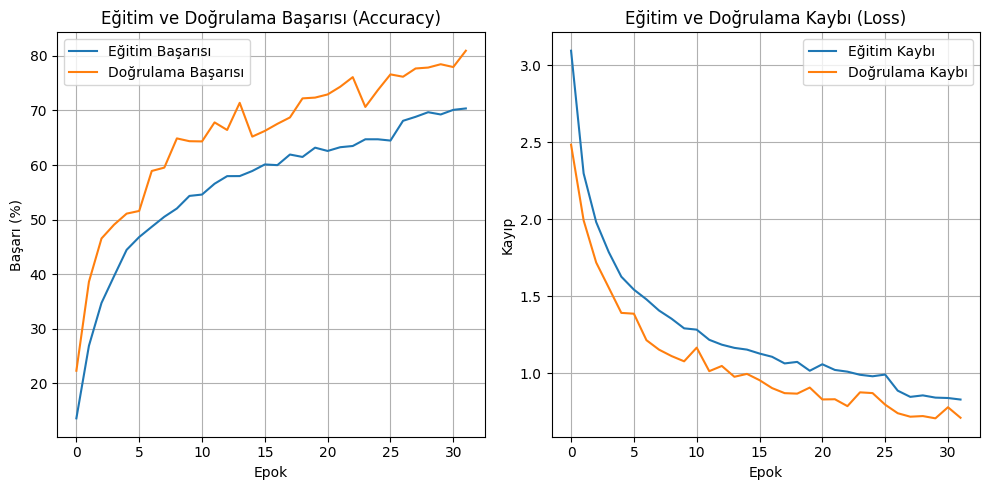

In [39]:
draw_accuracy_loss_plot(history['num_epochs'],history['train']["accuracy"],history['train']["loss"],history['validation']["accuracy"],history['validation']["loss"])

#### Precision, Recall ve F1-Score Grafikleri İncelenmesi


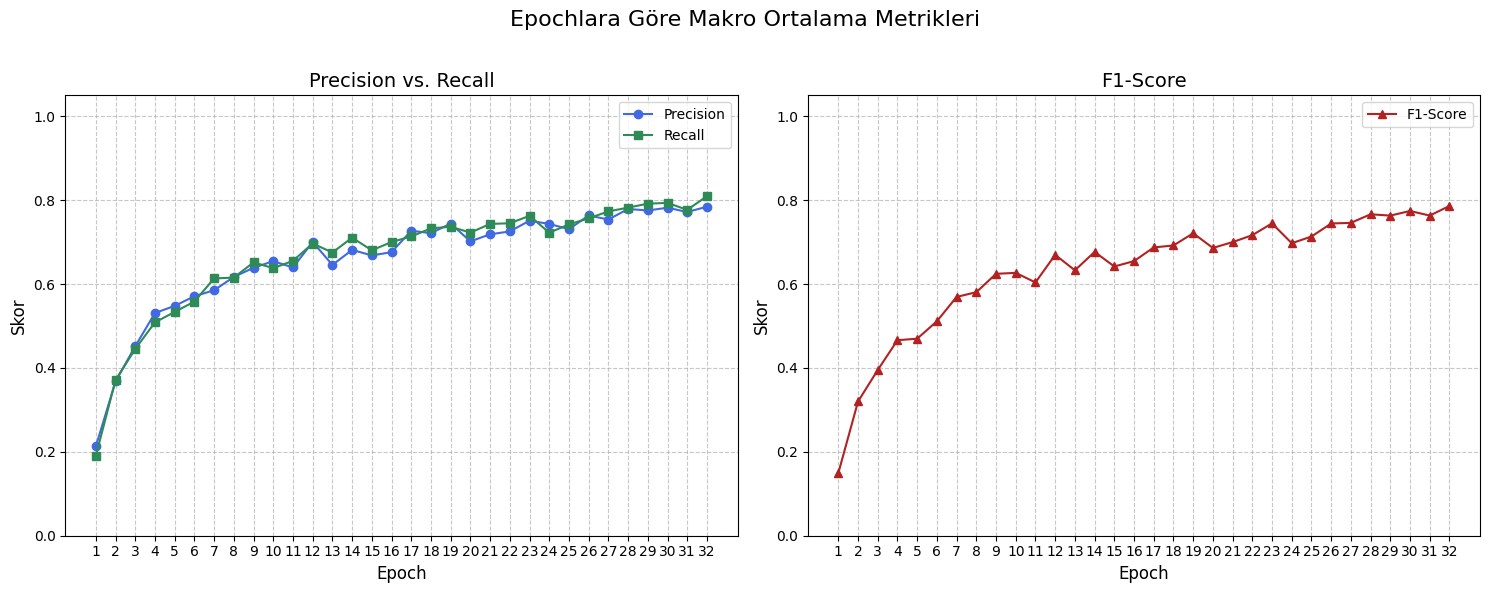

In [40]:
reports = calculate_metrics(history['num_epochs'],history["test"]["labels"],history["test"]["prediction"])
plot_epoch_metrics(reports)

#### Confusion Matrix Gösterimi

Alttaki grafikte gösterildiği gibi 5 ve 10 sınıfları arasındaki verilerin, tamamen doğru tahmin edildiği görülmektedir.

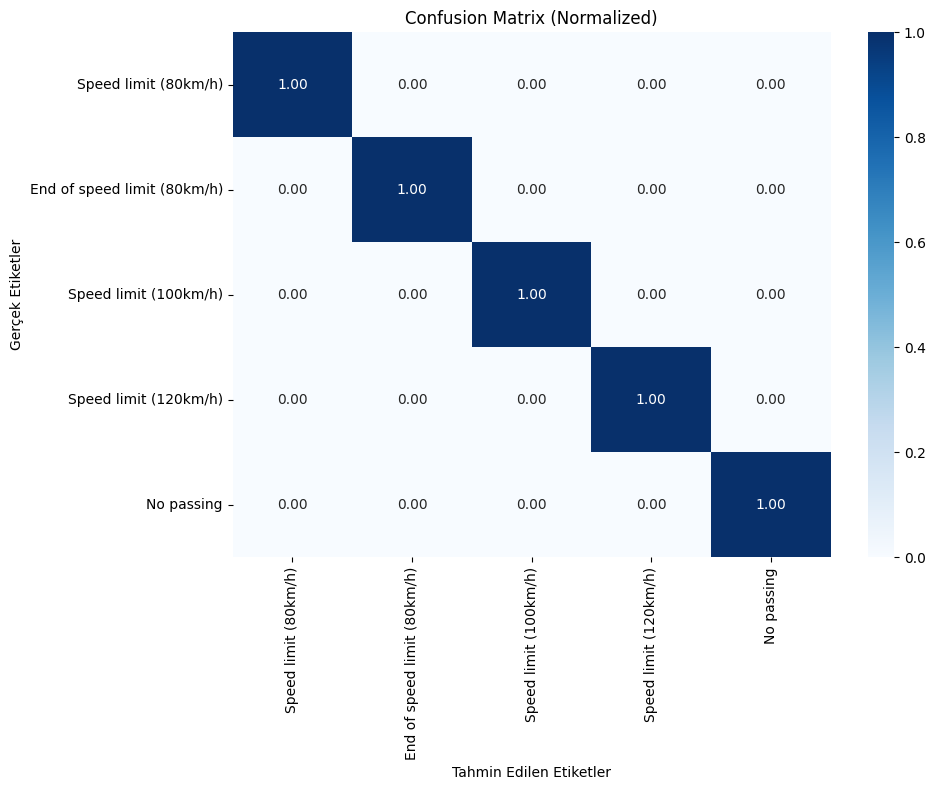

Sınıf 5,10 arasındaki Confusion Matrix Değeri


In [41]:
reports = calculate_confusion_matrix(history["test"]["prediction"][-1][5:10],history["test"]["labels"][-1][5:10])

plot_confusion_matrix(reports,labels["SignName"].tolist()[5:10])

print("Sınıf 5,10 arasındaki Confusion Matrix Değeri")


#### Metriklerin ve Heatmap Verilerinin İncelenmesi

Isı grafiği incelendiği kadarıyla, eğitilen verilerin sonucu olarak tabelanın şeklini, içindeki örüntüyü görebilmektedir. Bu durumda yuvarlak desenli tabelalarda daha başarılı sonuç gösterdiği söylenebilir fakat katman içerisine girilen görselin içindeki tabela için eğer içindeki öznitelik, görüntü kalitesinden dolayı tam olarak seçilemeyecek durumdaysa bile bir tahmin yapabiliyor fakat doğru olması zor gibi görünüyor.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


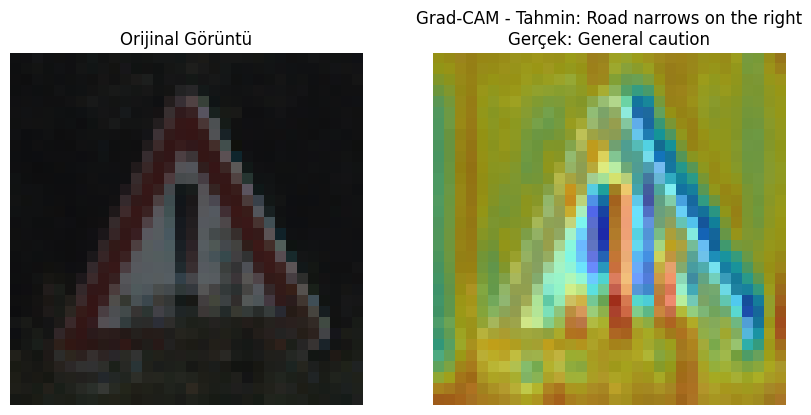

y_true: General caution - y_pred: Road narrows on the right


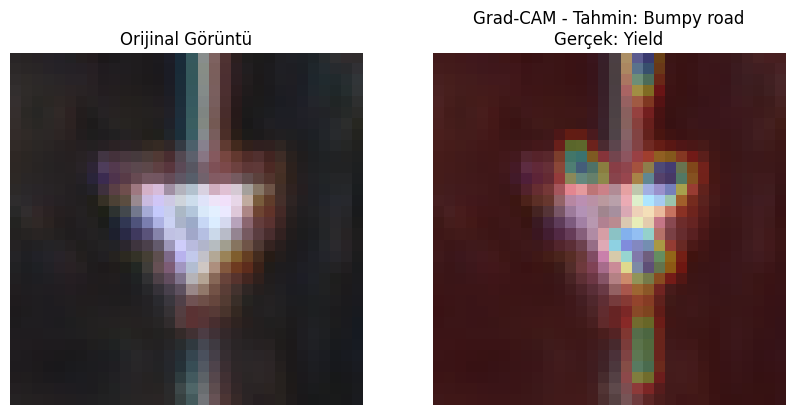

y_true: Yield - y_pred: Bumpy road


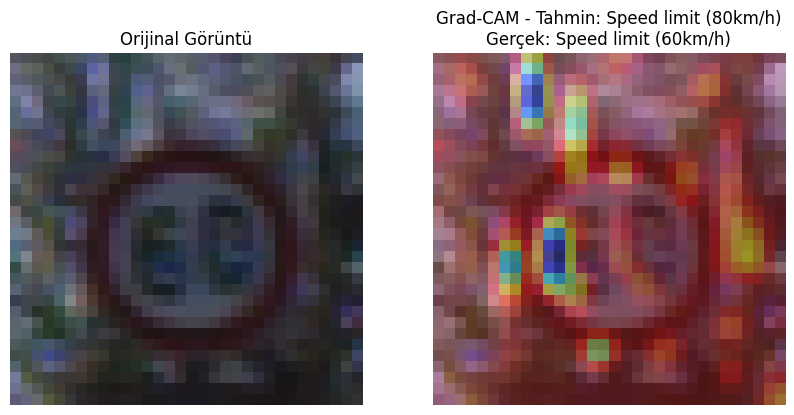

y_true: Speed limit (60km/h) - y_pred: Speed limit (80km/h)


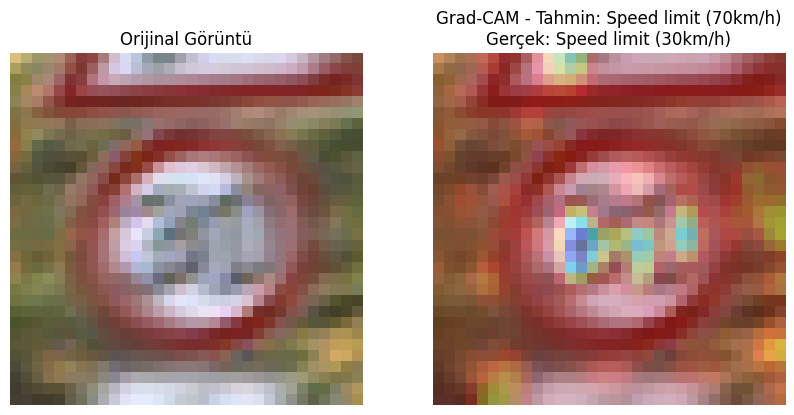

y_true: Speed limit (30km/h) - y_pred: Speed limit (70km/h)


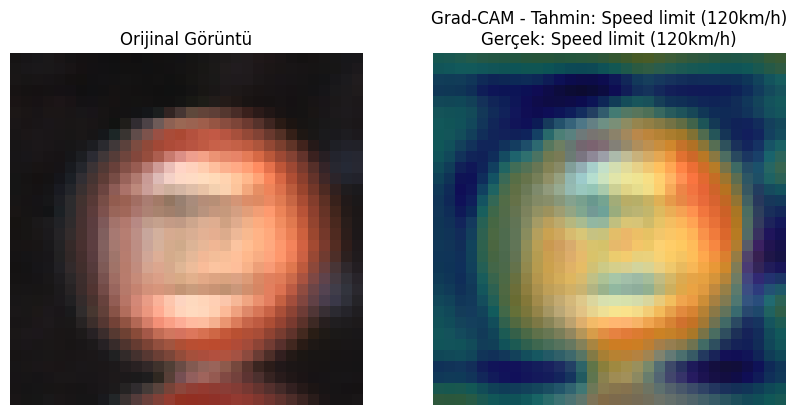

y_true: Speed limit (120km/h) - y_pred: Speed limit (120km/h)


In [42]:
import random
from typing import List

class_labels = labels["SignName"].tolist()
target_layer_name = 'features.4'

def show_heatmaps(limit:int,target_layer_name:str):
    
    grad_cam_instance = GradCAM(model, target_layer_name)
    choices = range(len(y_test))
    # Görüntü yolunuzu buraya yazın
    for i in range(limit):
        test_image_id = random.choice(choices)
        test_image = x_test[test_image_id]
        test_label = class_labels[y_test[test_image_id]]

        # Görüntüyü modele hazır hale getir
        preprocess = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
        ])
        input_tensor = preprocess(test_image).unsqueeze(0)
        input_tensor = input_tensor.to(device)
        # Grad-CAM hesapla ve görselleştir
        heatmap = grad_cam_instance(input_tensor)
        cam_image = show_cam_on_image(test_image, heatmap)
        
        # Sınıf tahminini al ve grafiği göster
        predicted_class = model(input_tensor).argmax().item()
        plot_gradcam(test_image/255, cam_image, class_labels[predicted_class],test_label)
        print(f"y_true: {test_label} - y_pred: {class_labels[predicted_class]}")

show_heatmaps(5,target_layer_name)

### İkinci Eğitim (Transfer Learning)

In [43]:

t2_class_weights = t2_class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=t2_class_weights)

history = train_model(model,criterion,optimizer,num_epochs,train2_dataloader,test_dataloader,device,True,True)


Epoch 1/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 1   - Train Loss:   0.8567   Train Accuracy: 70.22% | Validation Loss:   0.6984   Validation Accuracy: 80.76%  |  lr: [0.0005]


Epoch 2/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 2   - Train Loss:   0.8277   Train Accuracy: 70.56% | Validation Loss:   0.7174   Validation Accuracy: 79.06%  |  lr: [0.0005]
EarlyStop Counter: 1 / 5


Epoch 3/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

...

Epoch 20  - Train Loss:   0.7105   Train Accuracy: 75.22% | Validation Loss:   0.6085   Validation Accuracy: 84.20%  |  lr: [0.000125]
EarlyStop Counter: 3 / 5


Epoch 21/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 21  - Train Loss:   0.6616   Train Accuracy: 76.74% | Validation Loss:   0.5869   Validation Accuracy: 83.86%  |  lr: [0.000125]
EarlyStop Counter: 4 / 5


Epoch 22/32 (Train):   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 22  - Train Loss:   0.6738   Train Accuracy: 76.67% | Validation Loss:   0.5831   Validation Accuracy: 84.28%  |  lr: [0.000125]
EarlyStop Counter: 5 / 5
Erken Durdurma tetiklendi!


#### Başarı ve Kayıp Grafiği İncelenmesi

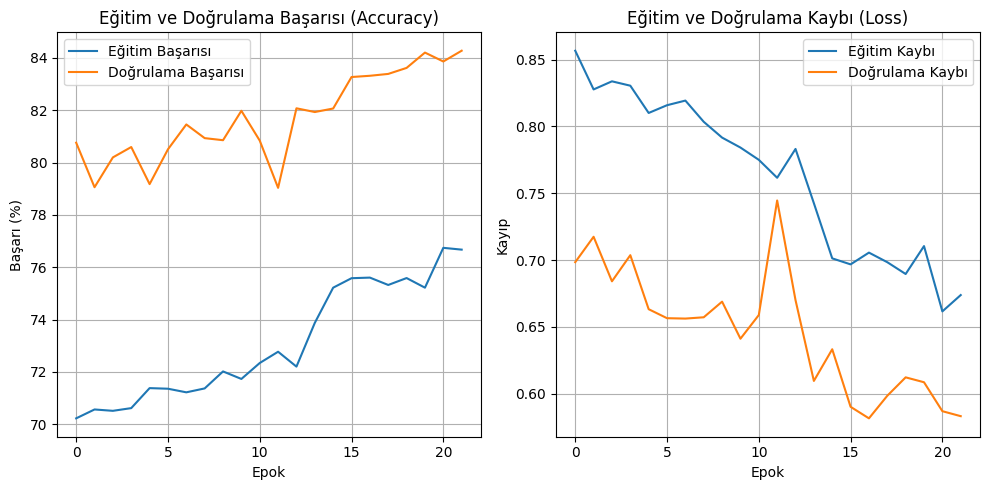

In [46]:
draw_accuracy_loss_plot(len(history['train']["accuracy"]),history['train']["accuracy"],history['train']["loss"],history['validation']["accuracy"],history['validation']["loss"])

#### Precision, Recall ve F1-Score Grafikleri İncelenmesi

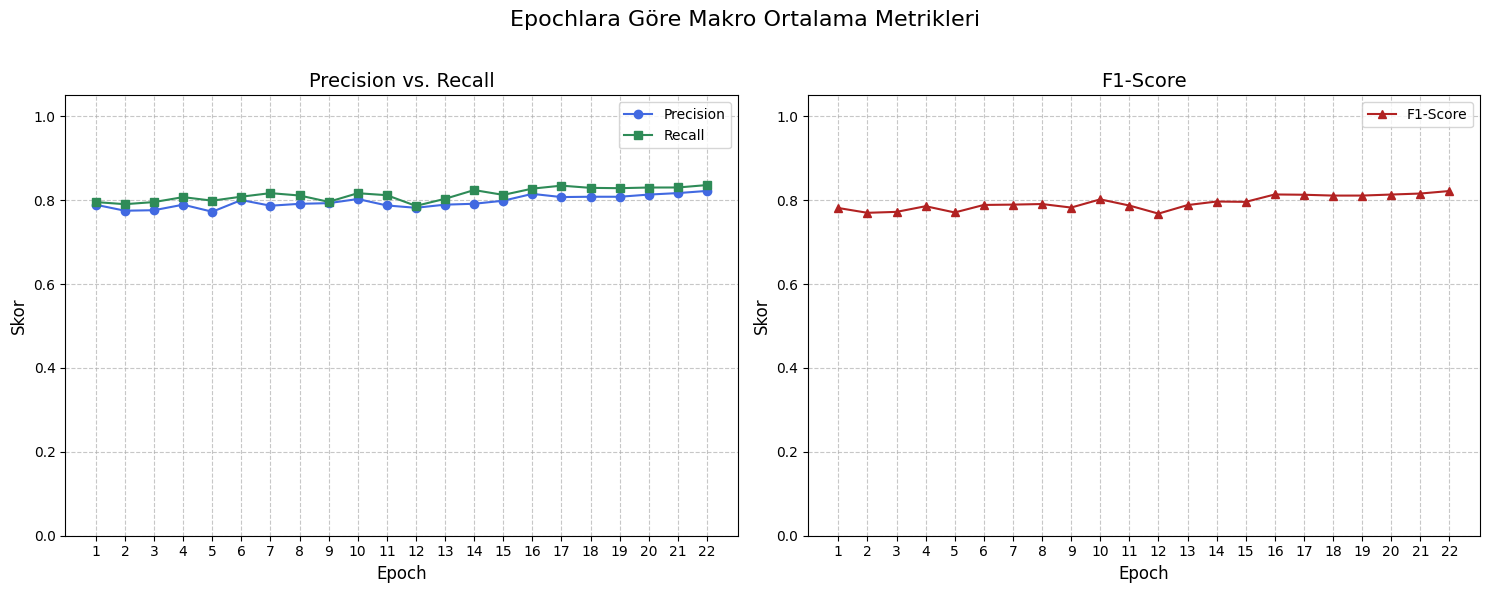

In [49]:
reports = calculate_metrics(len(history["test"]["labels"]),history["test"]["labels"],history["test"]["prediction"])
plot_epoch_metrics(reports)

#### Confusion Matrix Gösterimi

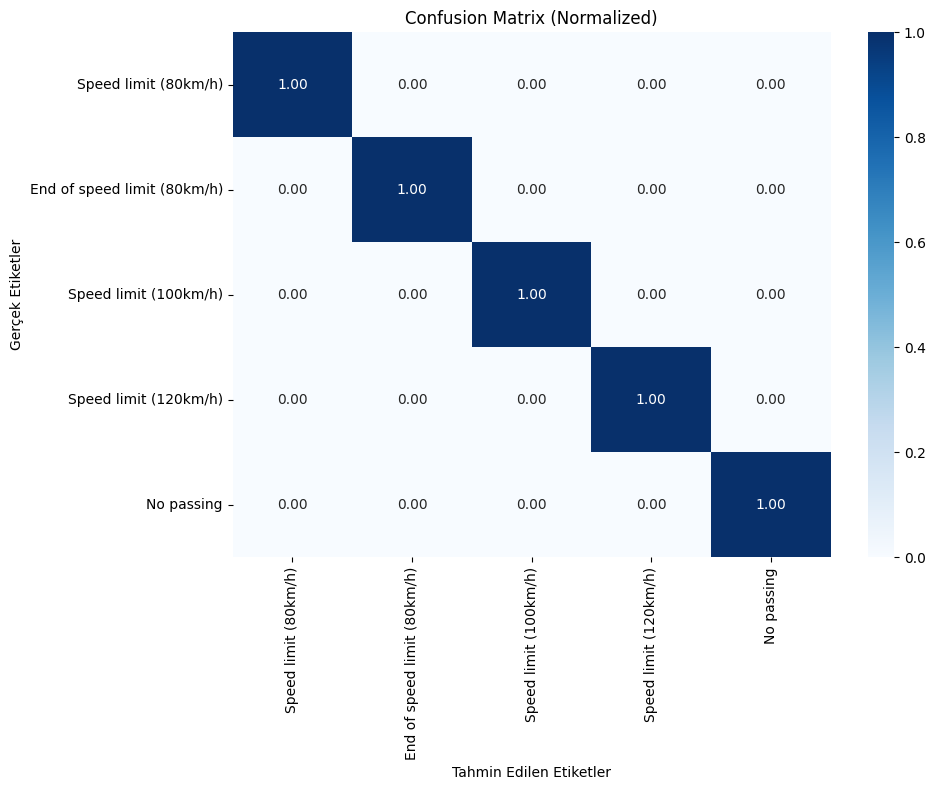

Sınıf 5,10 arasındaki Confusion Matrix Değeri


In [50]:
reports = calculate_confusion_matrix(history["test"]["prediction"][-1][5:10],history["test"]["labels"][-1][5:10])

plot_confusion_matrix(reports,labels["SignName"].tolist()[5:10])

print("Sınıf 5,10 arasındaki Confusion Matrix Değeri")


#### Metriklerin ve Heatmap Verilerinin İncelenmesi

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


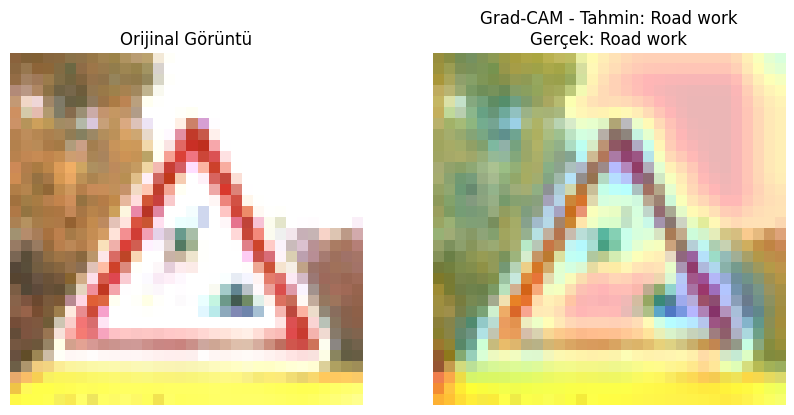

y_true: Road work - y_pred: Road work


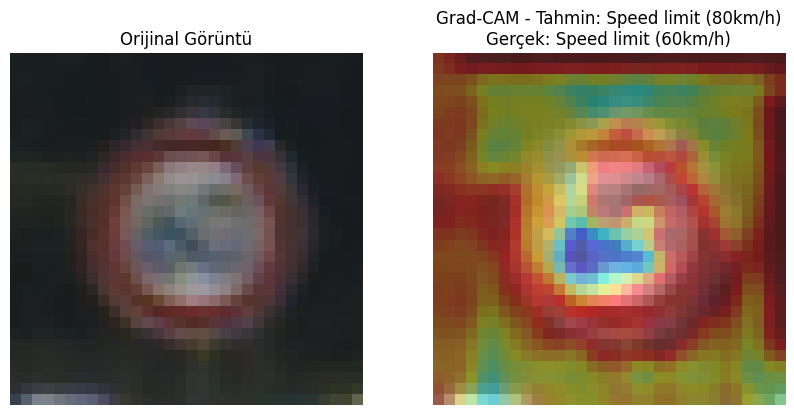

y_true: Speed limit (60km/h) - y_pred: Speed limit (80km/h)


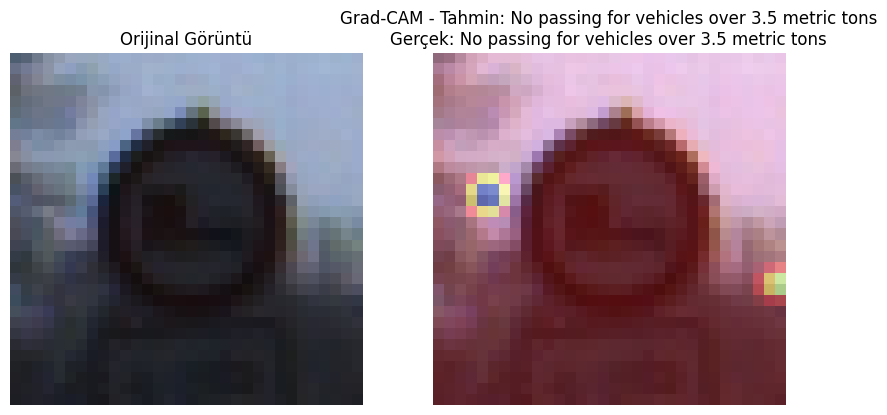

y_true: No passing for vehicles over 3.5 metric tons - y_pred: No passing for vehicles over 3.5 metric tons


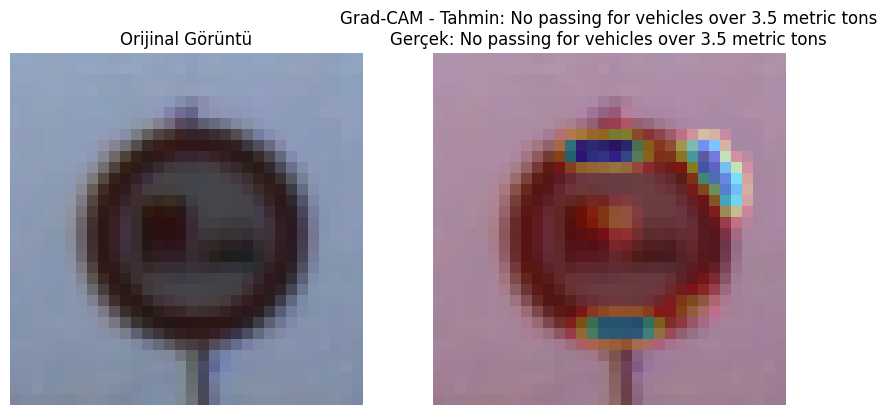

y_true: No passing for vehicles over 3.5 metric tons - y_pred: No passing for vehicles over 3.5 metric tons


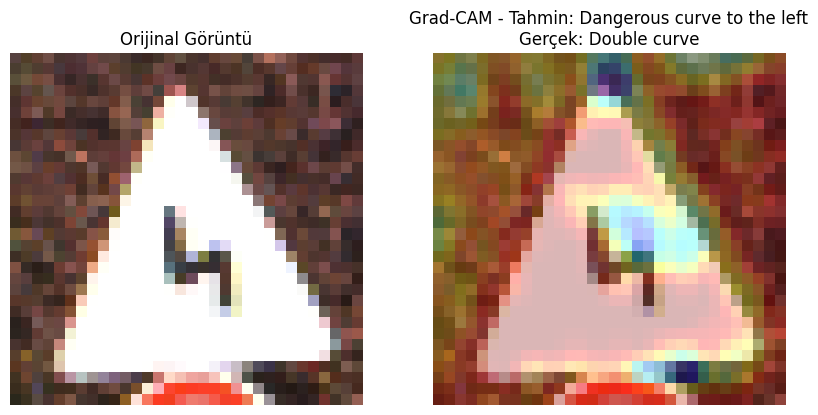

y_true: Double curve - y_pred: Dangerous curve to the left


In [51]:
import random
from typing import List

class_labels = labels["SignName"].tolist()
target_layer_name = 'features.4'

def show_heatmaps(limit:int,target_layer_name:str):
    
    grad_cam_instance = GradCAM(model, target_layer_name)
    choices = range(len(y_test))
    # Görüntü yolunuzu buraya yazın
    for i in range(limit):
        test_image_id = random.choice(choices)
        test_image = x_test[test_image_id]
        test_label = class_labels[y_test[test_image_id]]

        # Görüntüyü modele hazır hale getir
        preprocess = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
        ])
        input_tensor = preprocess(test_image).unsqueeze(0)
        input_tensor = input_tensor.to(device)
        # Grad-CAM hesapla ve görselleştir
        heatmap = grad_cam_instance(input_tensor)
        cam_image = show_cam_on_image(test_image, heatmap)
        
        # Sınıf tahminini al ve grafiği göster
        predicted_class = model(input_tensor).argmax().item()
        plot_gradcam(test_image/255, cam_image, class_labels[predicted_class],test_label)
        print(f"y_true: {test_label} - y_pred: {class_labels[predicted_class]}")

show_heatmaps(5,target_layer_name)

## Sonuçlar

Bu kısımda ise yapılan işlemler sonucunda elde edilen sonuçların tartışıldığı ve yorumlandığı kısım olacaktır.




### Veri seti Yorumları

Veri setinin, eğitim aşamasında sınıf dağılımlarının eşit olması, eğitim için en iyi unsurlardan birisi olarak kabul edilebilir. Test, validasyon verilerinin dengesiz olması ise bağımsız bir test süreci ile **Hiperparametre Optimizasyonu** yapabileceğimiz sonucunu çıkarmamızı sağlar. Kısacası veriler ile alakalı olabilecek tek sorunun ise yükseklik ve genişlik değerinin 32x32 olması diye düşünülebilir. Bu sonuç belki eğitimdeki katmanlar ayarlanarak aşırı öğrenme durumu olmadan atlatılabilir.

Eğitim verisinin kısmen düşük olması, eğitimin hızlanmasını göstereceği gibi iyi ayarlanmış katmanlar ile optimize bir sonuç çıkaracağı düşünülmektedir.



### Hiperparametre Optimizasyonu

Bu kısımın sonuçlarında ise çıkarılabilecek çok temel sonuçlar yer almaktadır. Tensor içince her birisi 3 kanal, genişlik ve yükseklik değerlerinin 32 olması, ayrıca validasyon verilerinin diğerlerine göre az olması bu durumun senaryolarını farklılaştırmaktadır. Kısacası uygulanacak katman sayısı, parametre değerleri gibi durumları dolaylı bir yoldan etkileyebilmektedir. Bu durumda en iyi hesaplama yöntemi ise düşünülecek olan en iyi parametre ve en kötüye yakın parametrelerdir.

Öğrenme katsayısının yüksek olduğu durumda model hiç eğitmeyebilir.

Dropout değeri yok ise parametreleri aşırı öğrenebilir ve doğrulama kısmında birbirinden alakasız sonuçlar verebilir.

Batch size değerinde ise değerin küçük olması, modeli ufak parçacıklarla eğitmesini sağlayacaktır. İyi tarafının düşük donanım seviyelerinde düşük kaynak tüketimi olarak yorumlansa da düşük verilerde gürültü seviyesini arttırarak öğrenme hızını yavaşlatabilir ya da hiç öğrenmeyebilir.

Öznitelik katmanı olarak isimlendirdiğimiz katmanlar listesinin fazla olması da düşük verilerde daha işe yarayabilir diye özetleyebiliriz. Çıkaracağı özniteliklerin fazla olması ise öğrenmeyi diğerlerine göre dengeleyebilir fakat aşırı öğrenmeye de itebilir. Bunu dropout katmanı ile dengelenmesi sağlanabilir.

Düşük katman için sonucun ise iyi eğitim gösteremeyeğini söyleyebiliriz. Bunun sebebi ise eğitilecek verinin az olması doğrudan etkilemektedir. Bu verilerin parametre sayılarının az olması ve katmanların öznitelik çıkaramayacak kadar az olması söylenebilir.

 ---
**Not**: Doğrulama verilerinin eğitim başarı oranlarının fazla çıkmasının en temel sebebi ise birbirine benzer eğitim verilerinin en iyi şekilde öğrenebilmesi, verilerin olabildiğince benzersiz ve artırılmış olmasının eğitimdeki katkısını arttıracağını söylenebilir fakat bu parametre testi olduğu için bağımsız veriler ile test edilmesi istenmiştir.  

Temel eğitim için çıkarılabilecek en temel sonuçlar şunu göstermektedir.
* Dropout ile gereksiz parametrelerden arındırılmasının aşırı öğrenmeye karşı en etkili yöntem olduğu,
* Düşük verilerde katman sayısının artmasının, filtre sayısının arttırılmasının modelin öznitelik çıkarımına sağlayacağı önemli bir etken olduğu,
* Öğrenme katsayısının yüksek kaldığı durumda ise düşük yoğunluktaki verilerin öğrenmesini yavaşlatacağı ya da hiç öğrenemeyeceği bir durum yarattığı ise ulaşabileceğimiz en temel sonuçları bize göstermektedir.

### Modelin Eğitilmesi

Modelin eğitilmesi için hiperparametre optimizasyonu kısmından elde edeceğimiz sonuçlar neticesinde yola çıkacağımız gösterilebilir.



#### Parametrelerin Hazırlanması

Bu aşamanın en önemli aşaması gereken hiperparametreleri tanımlamak denilebilir. Elimizde kısmen düşük verinin düşeceği bir veri seti yer almaktadır. Parametre testlerinde kullanılabilecek en iyi parametrelerin bile bu aşamada aşırı öğrenmeye rahatlıkla yönlendirebileceğini söylemek pek de zor değil. Kısacası kullanılacak katmanlar sayılarının sabit olacağını bile düşünürsek, değiştirmemiz gereken en önemli parametre filtre sayısını belirlen `num_filters` parametresidir. Evrişim katmanındaki ilk çıkış katmanının temsil eden bu verinin, zaten sayıca fazla olan görselden fazlasıyla öznitelik çıkarmasını istememizin getirebileceği en temel sonuç ise aşırı öğrenmedir. Ayrıca filtre sayısını arttırmanın eğitim süresine ekleyeceği ek donanım ihtiyacı ve süreyi de göz önüne alırsak pek mantıklı bir yöntem olmadığı söylenebilir. Ayrıca katmanlar arası parametre sayılarının tutarsızlığı ve artacak olan parametre sayısının, sınıflandırma aşamasında da sağlayacağı en zararlar bulunmaktadır. Sınıflandırma katmanı için girecek verinin boyutunun istenen değerlere yakın olması ve eklenecek katmanların birbirine olan yakın ilişkileri ise, modelin sınıflandırma başarısına da doğrudan katkı sağlayacaktır.

Bir diğer katman ise `BatchNormalization` ise, Evrişim Katmanından gelen verinin daha istikrarlı olması için eklenmesi gerektiğini düşünüyoruz. Tanımı gereği ortalamanın sıfıra yakın olmasının, standart sapmanın ise bir seviyesine yakın olmasının oluşacak veri kaybının önüne geçmesi olarak gösterilebilir. Halihazırda bu aşama, verilerin önişlenmesi kısmında detaylı olarak anlatılmıştır.

Bu aşırı öğrenmenin önüne geçebilecek en iyi katmanlardan birisi ise `Dropout` katmanı olduğu söylenebilir. Değeri ortalama seviyelerde tutarak veri kaybını önleme, aşırı öğrenme şamasının da önğne geçişmesi hedeflenir.

#### Eğitimin Sonucu

Eğitimin sonucu verilen parametreler dahilinde ilk eğitimin metrik verilerine göre Precision-Recall grafiğinin birbirine yakın ilerlemesinin sınıflandırma becerisini iyi bir şekilde yapabildiğini göstermektedir. Başarı ve kayıp grafiklerinin ise aralığının eşitim başarısı olarak iyi ilerlediğini gösterebilir fakat heatmap metrikleri incelendiğinde bazı nitelikleri çıkarmakta zorlandığı farkedilmektedir. Yuvarlak şekilde olan tabelalarda temel çıkarımı sağlayabiliyor fakat içerik olarak gerekli parametrelerde zorlandığı görülüyor.

İkinci eğitimin metrikleri incelendiğinde, eğitimin başarı oranının arttığını, fakat eğitimin son 10 epoch gibi değerlere geldiğinde durdurmaya başladığı görülüyor. Bu durum sonucunda ise öğrenme katsayısının düşmeye başladığı, doğrulama başarısındaki dalgalanma ise erken durdurmayı tetiklediği görülebilmektedir. Bu durumlar sonucunda modelin verileri öğrendiğini, ortalama bir şekilde sınıflandırmalara cevap verebildiği, içerik çıkarmada ilk eğitime göre daha iyi bir yol aldığı görülebilir. Precision-Recall grafiğindeki ufak dalgalanmalar ise eğitimin sonuna yaklaştığını, Confisuon Matrix grafiklerinde ise belirlenen 5 sınıf için başarılı bir tespit sağladığı görülmektedir. Heatmap grafiklerinde ise ilk eğitime göre öznitelik çıkarımındaki başarılar daha göz önüne çıkarmaktadır.